<div style="
background:#111827;
color:#e5e7eb;
border-radius:16px;
font-family:Arial, sans-serif;
line-height:1.6;
border:1px solid #374151;
overflow:hidden;
">

<!-- Header strip -->
<div style="
background:#0b1220;
padding:22px 28px;
border-bottom:1px solid #374151;
">

<div style="
font-size:12px;
letter-spacing:1.4px;
text-transform:uppercase;
color:#9ca3af;
font-weight:700;
margin-bottom:8px;
">
Expert Machine Learning Module
</div>

<h1 style="
color:#f9fafb;
margin:0;
font-size:26px;
font-weight:800;
line-height:1.25;
">
KDD Cup 1999 + Autoencoder Anomaly Detection
</h1>

<p style="
color:#9ca3af;
margin:10px 0 0 0;
font-size:14px;
">
Prepared by <strong style="color:#d1d5db;">Ruturaj Mokashi</strong>
</p>

</div>

<!-- Body -->
<div style="padding:28px;">

<h2 style="
color:#f3f4f6;
font-size:18px;
margin-top:0;
border-left:4px solid #6b7280;
padding-left:12px;
">
Project Goal
</h2>

<p>
In this expert section, we move from traditional outlier detection algorithms to a neural-network-based anomaly detection method called an <strong>Autoencoder</strong>.
</p>

<p>
We will use the <strong>KDD Cup 1999 network intrusion dataset</strong>. Each row represents one network connection. Some connections are normal, while others represent attack or intrusion behavior.
</p>

<div style="
background:#1f2937;
border:1px solid #4b5563;
border-left:4px solid #9ca3af;
padding:16px 18px;
border-radius:10px;
margin:22px 0;
">
<strong style="color:#f3f4f6;">Simple idea:</strong><br>
We teach the model what normal network traffic looks like. If a new connection looks very different from normal traffic, the model should treat it as suspicious.
</div>

<h2 style="
color:#f3f4f6;
font-size:18px;
border-left:4px solid #6b7280;
padding-left:12px;
">
What Is an Autoencoder?
</h2>

<p>
An Autoencoder is a neural network that learns to reconstruct its input.
</p>

<p>
It first compresses the data into a smaller hidden representation and then tries to rebuild the original input.
</p>

<ul>
<li><strong>Normal data</strong> should be reconstructed well.</li>
<li><strong>Anomalous data</strong> should be reconstructed poorly.</li>
<li><strong>High reconstruction error</strong> means possible anomaly.</li>
</ul>

<div style="
background:#0f172a;
border:1px solid #4b5563;
padding:18px;
border-radius:12px;
margin:22px 0;
text-align:center;
font-size:15px;
color:#e5e7eb;
">
Input data
&nbsp; → &nbsp;
Encoder
&nbsp; → &nbsp;
Compressed representation
&nbsp; → &nbsp;
Decoder
&nbsp; → &nbsp;
Reconstructed data
</div>

<h2 style="
color:#f3f4f6;
font-size:18px;
border-left:4px solid #6b7280;
padding-left:12px;
">
Workflow
</h2>

<ol>
<li>Load the KDD Cup 1999 dataset.</li>
<li>Explore the target labels.</li>
<li>Convert labels into normal vs anomaly.</li>
<li>Preprocess numerical and categorical features.</li>
<li>Train an Autoencoder mainly on normal data.</li>
<li>Calculate reconstruction error.</li>
<li>Choose an anomaly threshold.</li>
<li>Evaluate using Precision, Recall, and F1-score.</li>
<li>Compare Autoencoder results with Isolation Forest.</li>
</ol>

<div style="
background:#1f2937;
border:1px solid #4b5563;
padding:18px;
border-radius:12px;
margin-top:24px;
">
<h3 style="
color:#f3f4f6;
margin-top:0;
font-size:16px;
">
Business Interpretation
</h3>
<p style="margin-bottom:0;">
In real-world security monitoring, this approach can help identify suspicious network behavior without manually writing rules for every possible attack pattern.
</p>
</div>

</div>
</div>

In [1]:
# ============================================================
# Expert Section: KDD Cup 1999 + Autoencoder
# Load KDD Cup 1999 dataset
# ============================================================

import numpy as np
import pandas as pd

from sklearn.datasets import fetch_kddcup99

# ------------------------------------------------------------
# Project settings
# ------------------------------------------------------------

RANDOM_STATE = 42

# ------------------------------------------------------------
# Load KDD Cup 1999 dataset
# ------------------------------------------------------------

# percent10 = True loads the smaller 10% version of the dataset.
# This is still large, but manageable for notebook work.

kdd_data = fetch_kddcup99(
    percent10=True,
    as_frame=True,
    shuffle=True,
    random_state=RANDOM_STATE
)

# Separate features and target labels

X_kdd_raw = kdd_data.data.copy()
y_kdd_raw = kdd_data.target.copy()

print("KDD Cup 1999 dataset loaded successfully.")
print(f"Feature shape: {X_kdd_raw.shape}")
print(f"Target shape: {y_kdd_raw.shape}")

print("\nFirst 5 feature rows:")
display(X_kdd_raw.head())

print("\nFirst 10 target labels:")
display(y_kdd_raw.head(10))

KDD Cup 1999 dataset loaded successfully.
Feature shape: (494021, 41)
Target shape: (494021,)

First 5 feature rows:


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_count,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate
0,0,b'icmp',b'ecr_i',b'SF',1032,0,0,0,0,0,...,255,255,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,0,b'icmp',b'ecr_i',b'SF',1032,0,0,0,0,0,...,255,255,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0,b'icmp',b'ecr_i',b'SF',1032,0,0,0,0,0,...,255,255,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
3,0,b'tcp',b'http',b'SF',345,5419,0,0,0,0,...,101,255,1.0,0.0,0.01,0.02,0.0,0.0,0.0,0.0
4,0,b'tcp',b'private',b'S0',0,0,0,0,0,0,...,255,2,0.01,0.07,0.0,0.0,1.0,1.0,0.0,0.0



First 10 target labels:


0      b'smurf.'
1      b'smurf.'
2      b'smurf.'
3     b'normal.'
4    b'neptune.'
5      b'smurf.'
6    b'neptune.'
7     b'normal.'
8      b'smurf.'
9      b'smurf.'
Name: labels, dtype: object

<div style="
background:#111827;
color:#e5e7eb;
padding:24px;
border-radius:14px;
font-family:Arial, sans-serif;
line-height:1.6;
border:1px solid #374151;
">

<h2 style="color:#f3f4f6; margin-top:0;">
Conclusion — KDD Cup 1999 Dataset Loaded
</h2>

<p>
The <strong>KDD Cup 1999 dataset</strong> was loaded successfully.
</p>

<div style="
background:#1f2937;
border:1px solid #4b5563;
border-radius:10px;
padding:16px;
margin:18px 0;
">

<table style="width:100%; border-collapse:collapse; color:#e5e7eb;">
<tr>
<th style="text-align:left; padding:8px; border-bottom:1px solid #4b5563;">Item</th>
<th style="text-align:left; padding:8px; border-bottom:1px solid #4b5563;">Value</th>
</tr>
<tr>
<td style="padding:8px;">Number of rows</td>
<td style="padding:8px;"><strong>494,021</strong></td>
</tr>
<tr>
<td style="padding:8px;">Feature columns</td>
<td style="padding:8px;"><strong>41</strong></td>
</tr>
<tr>
<td style="padding:8px;">Target labels</td>
<td style="padding:8px;"><strong>494,021</strong></td>
</tr>
</table>

</div>

<p>
Each row represents one <strong>network connection</strong>.
</p>

<p>
The feature columns describe properties of each connection, such as protocol type, service, connection status, byte counts, and traffic behavior.
</p>

<p>
The target labels tell us whether each connection is <strong>normal</strong> or belongs to an <strong>attack category</strong>.
</p>

<div style="
background:#1f2937;
border-left:4px solid #9ca3af;
padding:14px 18px;
border-radius:10px;
margin-top:20px;
">
<strong style="color:#f3f4f6;">Next step:</strong><br>
We will inspect the target labels to understand how many normal and attack records exist in the dataset.
</div>

</div>

<div style="
background:#111827;
color:#e5e7eb;
border-radius:14px;
font-family:Arial, sans-serif;
line-height:1.6;
border:1px solid #374151;
overflow:hidden;
">

<div style="
background:#0b1220;
padding:18px 24px;
border-bottom:1px solid #374151;
">
<div style="
font-size:12px;
letter-spacing:1.2px;
text-transform:uppercase;
color:#9ca3af;
font-weight:700;
margin-bottom:6px;
">
Expert Section
</div>

<h2 style="
color:#f9fafb;
margin:0;
font-size:22px;
font-weight:800;
">
Step 2 — Inspect Target Labels
</h2>
</div>

<div style="padding:24px;">

<p>
Before building the Autoencoder, we need to understand the target labels in the KDD Cup 1999 dataset.
</p>

<p>
The target column tells us whether a network connection is normal or belongs to an attack category.
</p>

<div style="
background:#1f2937;
border-left:4px solid #9ca3af;
padding:15px 18px;
border-radius:10px;
margin:20px 0;
">
<strong style="color:#f3f4f6;">Goal of this step:</strong><br>
Check how many normal and attack records exist in the dataset.
</div>

<p>
This is important because anomaly detection datasets are usually imbalanced.
</p>

</div>
</div>

In [2]:
# ============================================================
# Step 2: Inspect target labels
# ============================================================

# Convert target labels to string format for easier reading.
# The original labels may be stored as byte strings.

y_kdd = y_kdd_raw.astype(str)

# Count each label

label_counts = (
    y_kdd
    .value_counts()
    .reset_index()
)

label_counts.columns = ["label", "row_count"]

# Add percentage

label_counts["percentage"] = (
    label_counts["row_count"] / len(y_kdd) * 100
).round(2)

print("Target label inspection completed.")
print(f"Number of unique labels: {label_counts.shape[0]}")

display(label_counts.head(15))

Target label inspection completed.
Number of unique labels: 23


,label,row_count,percentage
0,smurf.,280790,56.84
1,neptune.,107201,21.70
2,normal.,97278,19.69
3,back.,2203,0.45
4,satan.,1589,0.32
5,ipsweep.,1247,0.25
6,portsweep.,1040,0.21
7,warezclient.,1020,0.21
8,teardrop.,979,0.20
9,pod.,264,0.05


<div style="
background:#111827;
color:#e5e7eb;
border-radius:14px;
font-family:Arial, sans-serif;
line-height:1.6;
border:1px solid #374151;
overflow:hidden;
">

<div style="
background:#0b1220;
padding:18px 24px;
border-bottom:1px solid #374151;
">
<div style="
font-size:12px;
letter-spacing:1.2px;
text-transform:uppercase;
color:#9ca3af;
font-weight:700;
margin-bottom:6px;
">
Expert Section
</div>

<h2 style="
color:#f9fafb;
margin:0;
font-size:22px;
font-weight:800;
">
Step 2 Conclusion — Target Labels Inspected
</h2>
</div>

<div style="padding:24px;">

<p>
The target labels were inspected successfully.
</p>

<p>
The dataset contains <strong>23 unique labels</strong>. These labels include one normal class and multiple attack classes.
</p>

<div style="
background:#1f2937;
border:1px solid #4b5563;
border-radius:10px;
padding:16px;
margin:18px 0;
">

<table style="width:100%; border-collapse:collapse; color:#e5e7eb;">
<tr>
<th style="text-align:left; padding:8px; border-bottom:1px solid #4b5563;">Label</th>
<th style="text-align:left; padding:8px; border-bottom:1px solid #4b5563;">Rows</th>
<th style="text-align:left; padding:8px; border-bottom:1px solid #4b5563;">Percentage</th>
</tr>
<tr>
<td style="padding:8px;">smurf</td>
<td style="padding:8px;"><strong>280,790</strong></td>
<td style="padding:8px;"><strong>56.84%</strong></td>
</tr>
<tr>
<td style="padding:8px;">neptune</td>
<td style="padding:8px;"><strong>107,201</strong></td>
<td style="padding:8px;"><strong>21.70%</strong></td>
</tr>
<tr>
<td style="padding:8px;">normal</td>
<td style="padding:8px;"><strong>97,278</strong></td>
<td style="padding:8px;"><strong>19.69%</strong></td>
</tr>
</table>

</div>

<p>
The dataset is highly imbalanced because attack records are much more common than normal records.
</p>

<p>
This is important for anomaly detection because the Autoencoder should learn what normal traffic looks like and then identify records that behave differently.
</p>

<div style="
background:#1f2937;
border-left:4px solid #9ca3af;
padding:14px 18px;
border-radius:10px;
margin-top:20px;
">
<strong style="color:#f3f4f6;">Next step:</strong><br>
Convert the many labels into a simple binary target: <code>Normal</code> vs <code>Anomaly</code>.
</div>

</div>
</div>

<div style="
background:#111827;
color:#e5e7eb;
border-radius:14px;
font-family:Arial, sans-serif;
line-height:1.6;
border:1px solid #374151;
overflow:hidden;
">

<div style="
background:#0b1220;
padding:18px 24px;
border-bottom:1px solid #374151;
">
<div style="
font-size:12px;
letter-spacing:1.2px;
text-transform:uppercase;
color:#9ca3af;
font-weight:700;
margin-bottom:6px;
">
Expert Section
</div>

<h2 style="
color:#f9fafb;
margin:0;
font-size:22px;
font-weight:800;
">
Step 3 — Convert Labels into Normal vs Anomaly
</h2>
</div>

<div style="padding:24px;">

<p>
The KDD dataset has many labels such as <strong>normal</strong>, <strong>smurf</strong>, <strong>neptune</strong>, <strong>back</strong>, and others.
</p>

<p>
For anomaly detection, we simplify the labels into two groups:
</p>

<table style="width:100%; border-collapse:collapse; color:#e5e7eb; margin:18px 0;">
<tr>
<th style="text-align:left; padding:8px; border-bottom:1px solid #4b5563;">Original label type</th>
<th style="text-align:left; padding:8px; border-bottom:1px solid #4b5563;">New target</th>
<th style="text-align:left; padding:8px; border-bottom:1px solid #4b5563;">Meaning</th>
</tr>
<tr>
<td style="padding:8px;"><code>normal</code></td>
<td style="padding:8px;"><code>0</code></td>
<td style="padding:8px;">Normal connection</td>
</tr>
<tr>
<td style="padding:8px;">All attack labels</td>
<td style="padding:8px;"><code>1</code></td>
<td style="padding:8px;">Anomaly / attack connection</td>
</tr>
</table>

<div style="
background:#1f2937;
border-left:4px solid #9ca3af;
padding:15px 18px;
border-radius:10px;
margin-top:20px;
">
<strong style="color:#f3f4f6;">Goal of this step:</strong><br>
Create a binary target where <code>0</code> means normal and <code>1</code> means anomaly.
</div>

</div>
</div>

In [3]:
# ============================================================
# Step 3A: Convert KDD labels into normal vs anomaly
# ============================================================

# Clean label text.
# Some versions of the dataset may store labels as byte-like strings.
y_kdd_clean = (
    y_kdd
    .str.replace("b'", "", regex=False)
    .str.replace("'", "", regex=False)
    .str.replace(".", "", regex=False)
)

# Create binary target:
# 0 = normal connection
# 1 = anomaly / attack connection
y_kdd_binary = np.where(y_kdd_clean == "normal", 0, 1)

# Create readable label names for summary
binary_label_names = pd.Series(y_kdd_binary).map({
    0: "Normal",
    1: "Anomaly"
})

# Count normal vs anomaly
binary_label_summary = (
    binary_label_names
    .value_counts()
    .reset_index()
)

binary_label_summary.columns = ["connection_type", "row_count"]

binary_label_summary["percentage"] = (
    binary_label_summary["row_count"] / len(binary_label_names) * 100
).round(2)

print("Binary target created successfully.")
print("0 = Normal")
print("1 = Anomaly")

display(binary_label_summary)

Binary target created successfully.
0 = Normal
1 = Anomaly


,connection_type,row_count,percentage
0,Anomaly,396743,80.31
1,Normal,97278,19.69


<div style="
background:#111827;
color:#e5e7eb;
border-radius:14px;
font-family:Arial, sans-serif;
line-height:1.6;
border:1px solid #374151;
overflow:hidden;
">

<div style="
background:#0b1220;
padding:18px 24px;
border-bottom:1px solid #374151;
">
<div style="
font-size:12px;
letter-spacing:1.2px;
text-transform:uppercase;
color:#9ca3af;
font-weight:700;
margin-bottom:6px;
">
Expert Section
</div>

<h2 style="
color:#f9fafb;
margin:0;
font-size:22px;
font-weight:800;
">
Step 3A Conclusion — Binary Target Created
</h2>
</div>

<div style="padding:24px;">

<p>
The original KDD labels were successfully converted into a binary target.
</p>

<table style="width:100%; border-collapse:collapse; color:#e5e7eb; margin:18px 0;">
<tr>
<th style="text-align:left; padding:8px; border-bottom:1px solid #4b5563;">Connection Type</th>
<th style="text-align:left; padding:8px; border-bottom:1px solid #4b5563;">Rows</th>
<th style="text-align:left; padding:8px; border-bottom:1px solid #4b5563;">Percentage</th>
</tr>
<tr>
<td style="padding:8px;">Anomaly</td>
<td style="padding:8px;"><strong>396,743</strong></td>
<td style="padding:8px;"><strong>80.31%</strong></td>
</tr>
<tr>
<td style="padding:8px;">Normal</td>
<td style="padding:8px;"><strong>97,278</strong></td>
<td style="padding:8px;"><strong>19.69%</strong></td>
</tr>
</table>

<p>
The dataset is strongly dominated by attack/anomaly records.
</p>

<div style="
background:#1f2937;
border-left:4px solid #9ca3af;
padding:15px 18px;
border-radius:10px;
margin-top:20px;
">
<strong style="color:#f3f4f6;">Key point:</strong><br>
Even though anomaly rows are the majority in this dataset, the Autoencoder should learn from normal rows so it can detect connections that behave differently from normal traffic.
</div>

</div>
</div>

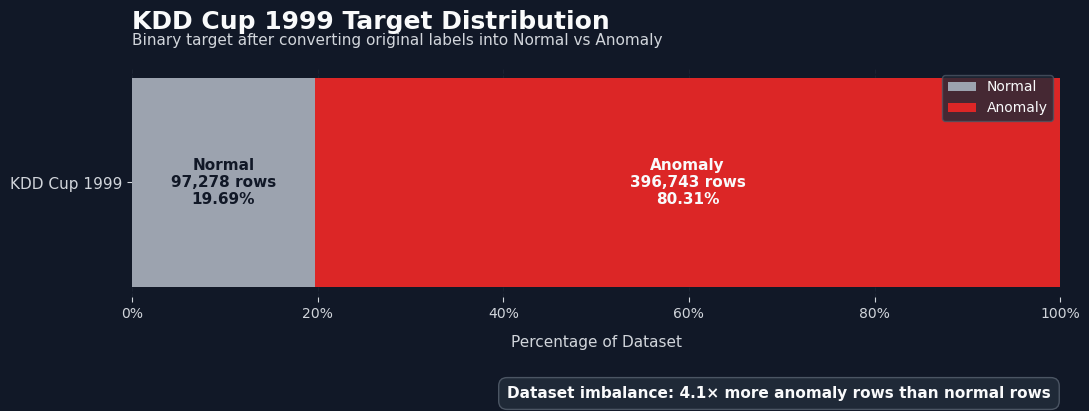

,connection_type,row_count,percentage
0,Normal,"97,278",19.69%
1,Anomaly,"396,743",80.31%


In [4]:
# ============================================================
# Step 3B: Professional chart - Normal vs Anomaly imbalance
# ============================================================

import matplotlib.pyplot as plt

# Prepare chart data
chart_data = binary_label_summary.set_index("connection_type").loc[
    ["Normal", "Anomaly"]
].reset_index()

normal_count = int(chart_data.loc[chart_data["connection_type"] == "Normal", "row_count"].iloc[0])
anomaly_count = int(chart_data.loc[chart_data["connection_type"] == "Anomaly", "row_count"].iloc[0])

normal_pct = float(chart_data.loc[chart_data["connection_type"] == "Normal", "percentage"].iloc[0])
anomaly_pct = float(chart_data.loc[chart_data["connection_type"] == "Anomaly", "percentage"].iloc[0])

total_count = normal_count + anomaly_count
imbalance_ratio = anomaly_count / normal_count

# ------------------------------------------------------------
# Create professional 100% stacked bar chart
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 4.8))

# Dark corporate background
fig.patch.set_facecolor("#111827")
ax.set_facecolor("#111827")

# Colors
normal_color = "#9CA3AF"
anomaly_color = "#DC2626"
text_color = "#F9FAFB"
muted_text = "#D1D5DB"
grid_color = "#374151"

# 100% stacked horizontal bar
ax.barh(
    y=["KDD Cup 1999"],
    width=[normal_pct],
    color=normal_color,
    height=0.42,
    label="Normal"
)

ax.barh(
    y=["KDD Cup 1999"],
    width=[anomaly_pct],
    left=[normal_pct],
    color=anomaly_color,
    height=0.42,
    label="Anomaly"
)

# Labels inside bars
ax.text(
    normal_pct / 2,
    0,
    f"Normal\n{normal_count:,} rows\n{normal_pct:.2f}%",
    ha="center",
    va="center",
    fontsize=11,
    fontweight="bold",
    color="#111827"
)

ax.text(
    normal_pct + anomaly_pct / 2,
    0,
    f"Anomaly\n{anomaly_count:,} rows\n{anomaly_pct:.2f}%",
    ha="center",
    va="center",
    fontsize=11,
    fontweight="bold",
    color=text_color
)

# Title and subtitle
ax.set_title(
    "KDD Cup 1999 Target Distribution",
    fontsize=18,
    fontweight="bold",
    loc="left",
    pad=28,
    color=text_color
)

ax.text(
    0,
    1.10,
    "Binary target after converting original labels into Normal vs Anomaly",
    transform=ax.transAxes,
    fontsize=11,
    color=muted_text
)

# Insight box
ax.text(
    0.99,
    -0.42,
    f"Dataset imbalance: {imbalance_ratio:.1f}× more anomaly rows than normal rows",
    transform=ax.transAxes,
    ha="right",
    va="center",
    fontsize=11,
    fontweight="bold",
    color=text_color,
    bbox=dict(
        boxstyle="round,pad=0.55",
        facecolor="#1F2937",
        edgecolor="#4B5563"
    )
)

# Axis formatting
ax.set_xlim(0, 100)
ax.set_xlabel("Percentage of Dataset", fontsize=11, color=muted_text, labelpad=10)

ax.set_xticks([0, 20, 40, 60, 80, 100])
ax.set_xticklabels([f"{x}%" for x in [0, 20, 40, 60, 80, 100]], color=muted_text)

ax.tick_params(axis="y", colors=muted_text, labelsize=11)
ax.tick_params(axis="x", colors=muted_text)

ax.grid(axis="x", linestyle="--", alpha=0.25, color=grid_color)
ax.set_axisbelow(True)

# Remove spines
for spine in ax.spines.values():
    spine.set_visible(False)

# Legend
legend = ax.legend(
    loc="upper right",
    frameon=True,
    facecolor="#1F2937",
    edgecolor="#4B5563",
    fontsize=10
)

for text in legend.get_texts():
    text.set_color(text_color)

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Clean summary table
# ------------------------------------------------------------

summary_table = chart_data.copy()
summary_table["row_count"] = summary_table["row_count"].map(lambda x: f"{int(x):,}")
summary_table["percentage"] = summary_table["percentage"].map(lambda x: f"{x:.2f}%")

display(summary_table)

<div style="
background:#111827;
color:#e5e7eb;
border-radius:14px;
font-family:Arial, sans-serif;
line-height:1.6;
border:1px solid #374151;
overflow:hidden;
">

<div style="
background:#0b1220;
padding:18px 24px;
border-bottom:1px solid #374151;
">
<div style="
font-size:12px;
letter-spacing:1.2px;
text-transform:uppercase;
color:#9ca3af;
font-weight:700;
margin-bottom:6px;
">
Expert Section
</div>

<h2 style="
color:#f9fafb;
margin:0;
font-size:22px;
font-weight:800;
">
Step 4 — Inspect Feature Types
</h2>
</div>

<div style="padding:24px;">

<p>
Before training an Autoencoder, we need to inspect the feature columns.
</p>

<p>
The KDD dataset contains two types of features:
</p>

<ul>
<li><strong>Numerical features</strong> — values such as duration, bytes, counts, and rates.</li>
<li><strong>Categorical features</strong> — text-like values such as protocol type, service, and connection flag.</li>
</ul>

<div style="
background:#1f2937;
border-left:4px solid #9ca3af;
padding:15px 18px;
border-radius:10px;
margin-top:20px;
">
<strong style="color:#f3f4f6;">Goal of this step:</strong><br>
Identify which columns need scaling and which columns need encoding.
</div>

</div>
</div>

In [5]:
# ============================================================
# Step 4A: Inspect numerical and categorical feature columns
# ============================================================

# Identify categorical columns

categorical_columns = X_kdd_raw.select_dtypes(include=["object", "category"]).columns.tolist()

# Identify numerical columns

numerical_columns = X_kdd_raw.select_dtypes(include=["number"]).columns.tolist()

print("Feature type inspection completed.")
print(f"Total feature columns: {X_kdd_raw.shape[1]}")
print(f"Numerical columns: {len(numerical_columns)}")
print(f"Categorical columns: {len(categorical_columns)}")

print("\nCategorical columns:")
print(categorical_columns)

print("\nFirst 10 numerical columns:")
print(numerical_columns[:10])

# Summary table

feature_type_summary = pd.DataFrame({
    "feature_type": ["Numerical", "Categorical"],
    "column_count": [len(numerical_columns), len(categorical_columns)]
})

display(feature_type_summary)

# Show sample categorical values

for col in categorical_columns:
    print(f"\nUnique sample values for {col}:")
    print(X_kdd_raw[col].astype(str).unique()[:10])

Feature type inspection completed.
Total feature columns: 41
Numerical columns: 0
Categorical columns: 41

Categorical columns:
['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate']

First 10 numerical columns:
[]


,feature_type,column_count
0,Numerical,0
1,Categorical,41



Unique sample values for duration:
<StringArray>
['0', '19757', '2592', '7', '35', '2630', '334', '15', '6911', '27']
Length: 10, dtype: str

Unique sample values for protocol_type:
<StringArray>
['icmp', 'tcp', 'udp']
Length: 3, dtype: str

Unique sample values for service:
<StringArray>
[   'ecr_i',     'http',  'private',    'other',     'uucp',      'ctf',
   'domain', 'ftp_data',     'smtp', 'domain_u']
Length: 10, dtype: str

Unique sample values for flag:
<StringArray>
['SF', 'S0', 'REJ', 'RSTO', 'RSTR', 'SH', 'S2', 'S1', 'RSTOS0', 'OTH']
Length: 10, dtype: str

Unique sample values for src_bytes:
<StringArray>
['1032', '345', '0', '309', '520', '235', '54540', '105', '233', '237']
Length: 10, dtype: str

Unique sample values for dst_bytes:
<StringArray>
['0', '5419', '1158', '309', '8314', '504', '1718', '237', '145', '105']
Length: 10, dtype: str

Unique sample values for land:
<StringArray>
['0', '1']
Length: 2, dtype: str

Unique sample values for wrong_fragment:
<StringArr

<div style="
background:#111827;
color:#e5e7eb;
border-radius:14px;
font-family:Arial, sans-serif;
line-height:1.6;
border:1px solid #374151;
overflow:hidden;
">

<div style="
background:#0b1220;
padding:18px 24px;
border-bottom:1px solid #374151;
">
<div style="
font-size:12px;
letter-spacing:1.2px;
text-transform:uppercase;
color:#9ca3af;
font-weight:700;
margin-bottom:6px;
">
Expert Section
</div>

<h2 style="
color:#f9fafb;
margin:0;
font-size:22px;
font-weight:800;
">
Step 4A Finding — Feature Types Need Correction
</h2>
</div>

<div style="padding:24px;">

<p>
The initial feature type inspection showed all 41 columns as categorical.
</p>

<p>
This happened because the KDD dataset was loaded with many numeric values stored as text.
</p>

<div style="
background:#1f2937;
border-left:4px solid #9ca3af;
padding:15px 18px;
border-radius:10px;
margin:20px 0;
">
<strong style="color:#f3f4f6;">Important correction:</strong><br>
Only <code>protocol_type</code>, <code>service</code>, and <code>flag</code> are truly categorical.  
The other columns should be converted into numeric format.
</div>

<p>
In the next step, we will clean the feature types before preprocessing.
</p>

</div>
</div>

In [6]:
# ============================================================
# Step 4B: Correct feature types
# ============================================================

# Create a clean feature dataframe
X_kdd_clean = X_kdd_raw.copy()

# These are the true categorical columns in the KDD dataset
categorical_columns = ["protocol_type", "service", "flag"]

# All other columns should be numeric
numerical_columns = [
    col for col in X_kdd_clean.columns
    if col not in categorical_columns
]

# Convert numerical columns from text/object into numeric values
for col in numerical_columns:
    X_kdd_clean[col] = pd.to_numeric(X_kdd_clean[col], errors="coerce")

# Convert categorical columns to string
for col in categorical_columns:
    X_kdd_clean[col] = X_kdd_clean[col].astype(str)

# Check corrected feature types
corrected_numerical_columns = X_kdd_clean.select_dtypes(include=["number"]).columns.tolist()
corrected_categorical_columns = X_kdd_clean.select_dtypes(include=["object", "category"]).columns.tolist()

print("Feature type correction completed.")
print(f"Total feature columns: {X_kdd_clean.shape[1]}")
print(f"Numerical columns after correction: {len(corrected_numerical_columns)}")
print(f"Categorical columns after correction: {len(corrected_categorical_columns)}")

print("\nCategorical columns:")
print(corrected_categorical_columns)

print("\nFirst 10 numerical columns:")
print(corrected_numerical_columns[:10])

# Summary table
corrected_feature_type_summary = pd.DataFrame({
    "feature_type": ["Numerical", "Categorical"],
    "column_count": [
        len(corrected_numerical_columns),
        len(corrected_categorical_columns)
    ]
})

display(corrected_feature_type_summary)

# Preview corrected data types
display(X_kdd_clean.dtypes.value_counts().to_frame("column_count"))

Feature type correction completed.
Total feature columns: 41
Numerical columns after correction: 38
Categorical columns after correction: 3

Categorical columns:
['protocol_type', 'service', 'flag']

First 10 numerical columns:
['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised']


/var/folders/j4/kqn10frs6hn7xq2lgsy0zv840000gn/T/ipykernel_27965/773080630.py:27: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  corrected_categorical_columns = X_kdd_clean.select_dtypes(include=["object", "category"]).columns.tolist()


,feature_type,column_count
0,Numerical,38
1,Categorical,3


,column_count
int64,23
float64,15
str,3


<div style="
background:#111827;
color:#e5e7eb;
border-radius:14px;
font-family:Arial, sans-serif;
line-height:1.6;
border:1px solid #374151;
overflow:hidden;
">

<div style="
background:#0b1220;
padding:18px 24px;
border-bottom:1px solid #374151;
">
<div style="
font-size:12px;
letter-spacing:1.2px;
text-transform:uppercase;
color:#9ca3af;
font-weight:700;
margin-bottom:6px;
">
Expert Section
</div>

<h2 style="
color:#f9fafb;
margin:0;
font-size:22px;
font-weight:800;
">
Step 4B Conclusion — Feature Types Corrected
</h2>
</div>

<div style="padding:24px;">

<p>
The KDD feature types were corrected successfully.
</p>

<p>
At first, all 41 columns appeared as categorical because many numeric values were stored as text.
</p>

<p>
After correction, the dataset now has:
</p>

<table style="width:100%; border-collapse:collapse; color:#e5e7eb; margin:18px 0;">
<tr>
<th style="text-align:left; padding:8px; border-bottom:1px solid #4b5563;">Feature Type</th>
<th style="text-align:left; padding:8px; border-bottom:1px solid #4b5563;">Column Count</th>
</tr>
<tr>
<td style="padding:8px;">Numerical</td>
<td style="padding:8px;"><strong>38</strong></td>
</tr>
<tr>
<td style="padding:8px;">Categorical</td>
<td style="padding:8px;"><strong>3</strong></td>
</tr>
</table>

<p>
The true categorical columns are:
</p>

<ul>
<li><code>protocol_type</code></li>
<li><code>service</code></li>
<li><code>flag</code></li>
</ul>

<div style="
background:#1f2937;
border-left:4px solid #9ca3af;
padding:15px 18px;
border-radius:10px;
margin-top:20px;
">
<strong style="color:#f3f4f6;">Next step:</strong><br>
We will preprocess the data by scaling numerical columns and encoding categorical columns.
</div>

</div>
</div>

<div style="
background:#111827;
color:#e5e7eb;
border-radius:14px;
font-family:Arial, sans-serif;
line-height:1.6;
border:1px solid #374151;
overflow:hidden;
">

<div style="
background:#0b1220;
padding:18px 24px;
border-bottom:1px solid #374151;
">
<div style="
font-size:12px;
letter-spacing:1.2px;
text-transform:uppercase;
color:#9ca3af;
font-weight:700;
margin-bottom:6px;
">
Expert Section
</div>

<h2 style="
color:#f9fafb;
margin:0;
font-size:22px;
font-weight:800;
">
Step 5 — Create Train and Test Sets
</h2>
</div>

<div style="padding:24px;">

<p>
Now we split the KDD dataset into training and testing sets.
</p>

<p>
The Autoencoder should learn what <strong>normal network traffic</strong> looks like.
</p>

<p>
Therefore, after splitting the data, we will create a special training set that contains only normal connections.
</p>

<div style="
background:#1f2937;
border-left:4px solid #9ca3af;
padding:15px 18px;
border-radius:10px;
margin-top:20px;
">
<strong style="color:#f3f4f6;">Goal of this step:</strong><br>
Create a train/test split and separate normal training rows for Autoencoder training.
</div>

</div>
</div>

In [7]:
# ============================================================
# Step 5A: Create train/test split and normal training data
# ============================================================

from sklearn.model_selection import train_test_split

# Split the dataset into train and test sets
# stratify=y_kdd_binary keeps the Normal/Anomaly ratio similar in both sets.

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_kdd_clean,
    y_kdd_binary,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_kdd_binary
)

# Autoencoder training data:
# use only normal rows from the training set

X_train_normal_raw = X_train_raw[y_train == 0].copy()

# Summary table

split_summary = pd.DataFrame({
    "dataset_part": [
        "Full dataset",
        "Training set",
        "Test set",
        "Normal rows for Autoencoder training"
    ],
    "row_count": [
        len(X_kdd_clean),
        len(X_train_raw),
        len(X_test_raw),
        len(X_train_normal_raw)
    ]
})

split_summary["percentage_of_full_dataset"] = (
    split_summary["row_count"] / len(X_kdd_clean) * 100
).round(2)

print("Train/test split completed.")
print(f"Training set shape: {X_train_raw.shape}")
print(f"Test set shape: {X_test_raw.shape}")
print(f"Normal training rows for Autoencoder: {X_train_normal_raw.shape}")

display(split_summary)

Train/test split completed.
Training set shape: (395216, 41)
Test set shape: (98805, 41)
Normal training rows for Autoencoder: (77822, 41)


,dataset_part,row_count,percentage_of_full_dataset
0,Full dataset,494021,100.00
1,Training set,395216,80.00
2,Test set,98805,20.00
3,Normal rows for Autoencoder training,77822,15.75


<div style="
background:#111827;
color:#e5e7eb;
border-radius:14px;
font-family:Arial, sans-serif;
line-height:1.6;
border:1px solid #374151;
overflow:hidden;
">

<div style="
background:#0b1220;
padding:18px 24px;
border-bottom:1px solid #374151;
">
<div style="
font-size:12px;
letter-spacing:1.2px;
text-transform:uppercase;
color:#9ca3af;
font-weight:700;
margin-bottom:6px;
">
Expert Section
</div>

<h2 style="
color:#f9fafb;
margin:0;
font-size:22px;
font-weight:800;
">
Step 5A Conclusion — Train and Test Sets Created
</h2>
</div>

<div style="padding:24px;">

<p>
The KDD dataset was split into training and testing sets successfully.
</p>

<table style="width:100%; border-collapse:collapse; color:#e5e7eb; margin:18px 0;">
<tr>
<th style="text-align:left; padding:8px; border-bottom:1px solid #4b5563;">Dataset Part</th>
<th style="text-align:left; padding:8px; border-bottom:1px solid #4b5563;">Rows</th>
<th style="text-align:left; padding:8px; border-bottom:1px solid #4b5563;">Percentage of Full Dataset</th>
</tr>
<tr>
<td style="padding:8px;">Full dataset</td>
<td style="padding:8px;"><strong>494,021</strong></td>
<td style="padding:8px;"><strong>100.00%</strong></td>
</tr>
<tr>
<td style="padding:8px;">Training set</td>
<td style="padding:8px;"><strong>395,216</strong></td>
<td style="padding:8px;"><strong>80.00%</strong></td>
</tr>
<tr>
<td style="padding:8px;">Test set</td>
<td style="padding:8px;"><strong>98,805</strong></td>
<td style="padding:8px;"><strong>20.00%</strong></td>
</tr>
<tr>
<td style="padding:8px;">Normal rows for Autoencoder training</td>
<td style="padding:8px;"><strong>77,822</strong></td>
<td style="padding:8px;"><strong>15.75%</strong></td>
</tr>
</table>

<p>
The Autoencoder will be trained mainly on the <strong>77,822 normal rows</strong>.
</p>

<div style="
background:#1f2937;
border-left:4px solid #9ca3af;
padding:15px 18px;
border-radius:10px;
margin-top:20px;
">
<strong style="color:#f3f4f6;">Key idea:</strong><br>
The Autoencoder learns normal network behavior first. Later, rows with high reconstruction error will be treated as possible anomalies.
</div>

</div>
</div>

<div style="
background:#111827;
color:#e5e7eb;
border-radius:14px;
font-family:Arial, sans-serif;
line-height:1.6;
border:1px solid #374151;
overflow:hidden;
">

<div style="
background:#0b1220;
padding:18px 24px;
border-bottom:1px solid #374151;
">
<div style="
font-size:12px;
letter-spacing:1.2px;
text-transform:uppercase;
color:#9ca3af;
font-weight:700;
margin-bottom:6px;
">
Expert Section
</div>

<h2 style="
color:#f9fafb;
margin:0;
font-size:22px;
font-weight:800;
">
Step 6 — Preprocess Features for Autoencoder
</h2>
</div>

<div style="padding:24px;">

<p>
The Autoencoder needs all input features to be numerical.
</p>

<p>
The KDD dataset contains:
</p>

<ul>
<li><strong>38 numerical columns</strong> — scaled using <code>StandardScaler</code></li>
<li><strong>3 categorical columns</strong> — encoded using one-hot encoding</li>
</ul>

<div style="
background:#1f2937;
border-left:4px solid #9ca3af;
padding:15px 18px;
border-radius:10px;
margin-top:20px;
">
<strong style="color:#f3f4f6;">Important:</strong><br>
The preprocessing is fitted on normal training rows only.  
This helps the Autoencoder learn the structure of normal network traffic.
</div>

</div>
</div>

In [8]:
# ============================================================
# Step 6A: Preprocess features for Autoencoder
# ============================================================

# Why this step is needed:

# The Autoencoder is a neural network.
# Neural networks can only work with numerical input.

# Our KDD dataset has:
# - 38 numerical columns
# - 3 categorical columns: protocol_type, service, flag

# So we need to:
# 1. Fill missing numerical values
# 2. Scale numerical columns
# 3. Fill missing categorical values
# 4. Convert categorical columns into numeric one-hot columns
# 5. Transform train/test data into final numeric arrays

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer


# ------------------------------------------------------------
# 1. Create OneHotEncoder for categorical columns
# ------------------------------------------------------------

# One-hot encoding converts text categories into numeric columns.

# Example:
# protocol_type = tcp / udp / icmp

# becomes:
# protocol_type_tcp
# protocol_type_udp
# protocol_type_icmp

# handle_unknown="ignore" means:
# If the test data contains a category not seen during training,
# the code will not crash.

try:
    one_hot_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    )
except TypeError:
    
    # Older scikit-learn versions use sparse=False instead of sparse_output=False
    
    one_hot_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse=False
    )


# ------------------------------------------------------------
# 2. Create preprocessing steps for numerical columns
# ------------------------------------------------------------

# Numerical columns contain values like:
# duration, src_bytes, dst_bytes, count, error rates, etc.

# Step 1: SimpleImputer(strategy="median")
# - fills missing numerical values using the median value

# Step 2: StandardScaler()

# - scales numerical values so they are comparable
# - mean becomes approximately 0
# - standard deviation becomes approximately 1

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)


# ------------------------------------------------------------
# 3. Create preprocessing steps for categorical columns
# ------------------------------------------------------------

# Categorical columns contain text-like values:

# - protocol_type
# - service
# - flag

# Step 1: SimpleImputer(strategy="most_frequent")

# - fills missing categorical values using the most common value

# Step 2: OneHotEncoder()

# - converts categories into numeric columns

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", one_hot_encoder)
    ]
)


# ------------------------------------------------------------
# 4. Combine numerical and categorical preprocessing
# ------------------------------------------------------------

# ColumnTransformer lets us apply different preprocessing
# to different column groups.

# Numerical columns:

# - impute missing values
# - scale values
#
# Categorical columns:

# - impute missing values
# - one-hot encode values

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, corrected_numerical_columns),
        ("categorical", categorical_pipeline, corrected_categorical_columns)
    ],
    remainder="drop"
)


# ------------------------------------------------------------
# 5. Fit preprocessing only on normal training rows
# ------------------------------------------------------------

# This is important for Autoencoder anomaly detection.

# The Autoencoder should learn normal network behavior.
# So the preprocessing is fitted on normal training data.

# "fit" means:
# - learn medians for numerical columns
# - learn means and standard deviations for scaling
# - learn categorical values for one-hot encoding

preprocessor.fit(X_train_normal_raw)


# ------------------------------------------------------------
# 6. Transform the datasets
# ------------------------------------------------------------

# "transform" applies the learned preprocessing rules.

# We transform:

# - normal training data: used to train the Autoencoder
# - full training data: useful for analysis/evaluation
# - test data: used to evaluate anomaly detection performance

X_train_normal_processed = preprocessor.transform(X_train_normal_raw)
X_train_processed = preprocessor.transform(X_train_raw)
X_test_processed = preprocessor.transform(X_test_raw)


# ------------------------------------------------------------
# 7. Convert arrays to float32
# ------------------------------------------------------------

# Neural networks work efficiently with float32.
# This also reduces memory usage compared to float64.

X_train_normal_processed = X_train_normal_processed.astype("float32")
X_train_processed = X_train_processed.astype("float32")
X_test_processed = X_test_processed.astype("float32")


# ------------------------------------------------------------
# 8. Print final preprocessing summary
# ------------------------------------------------------------

print("Feature preprocessing completed.")
print(f"Normal training input shape: {X_train_normal_processed.shape}")
print(f"Full training input shape: {X_train_processed.shape}")
print(f"Test input shape: {X_test_processed.shape}")

print("\nPreprocessing summary:")
print(f"Numerical columns scaled: {len(corrected_numerical_columns)}")
print(f"Categorical columns encoded: {len(corrected_categorical_columns)}")
print(f"Final processed feature count: {X_train_normal_processed.shape[1]}")

Feature preprocessing completed.
Normal training input shape: (77822, 74)
Full training input shape: (395216, 74)
Test input shape: (98805, 74)

Preprocessing summary:
Numerical columns scaled: 38
Categorical columns encoded: 3
Final processed feature count: 74


- Raw KDD data
      ↓
- Fix missing values
      ↓
- Scale numerical columns
      ↓
- Encode categorical columns
      ↓
- Create final numeric data
      ↓
- Ready for Autoencoder

<div style="
background:#111827;
color:#e5e7eb;
border-radius:14px;
font-family:Arial, sans-serif;
line-height:1.6;
border:1px solid #374151;
overflow:hidden;
">

<div style="
background:#0b1220;
padding:18px 24px;
border-bottom:1px solid #374151;
">
<div style="
font-size:12px;
letter-spacing:1.2px;
text-transform:uppercase;
color:#9ca3af;
font-weight:700;
margin-bottom:6px;
">
Expert Section
</div>

<h2 style="
color:#f9fafb;
margin:0;
font-size:22px;
font-weight:800;
">
Step 6A Conclusion — Features Preprocessed Successfully
</h2>
</div>

<div style="padding:24px;">

<p>
The KDD dataset was successfully converted into a numerical format for Autoencoder training.
</p>

<table style="width:100%; border-collapse:collapse; color:#e5e7eb; margin:18px 0;">
<tr>
<th style="text-align:left; padding:8px; border-bottom:1px solid #4b5563;">Item</th>
<th style="text-align:left; padding:8px; border-bottom:1px solid #4b5563;">Result</th>
</tr>
<tr>
<td style="padding:8px;">Normal training input shape</td>
<td style="padding:8px;"><strong>77,822 × 74</strong></td>
</tr>
<tr>
<td style="padding:8px;">Full training input shape</td>
<td style="padding:8px;"><strong>395,216 × 74</strong></td>
</tr>
<tr>
<td style="padding:8px;">Test input shape</td>
<td style="padding:8px;"><strong>98,805 × 74</strong></td>
</tr>
<tr>
<td style="padding:8px;">Numerical columns scaled</td>
<td style="padding:8px;"><strong>38</strong></td>
</tr>
<tr>
<td style="padding:8px;">Categorical columns encoded</td>
<td style="padding:8px;"><strong>3</strong></td>
</tr>
<tr>
<td style="padding:8px;">Final processed feature count</td>
<td style="padding:8px;"><strong>74</strong></td>
</tr>
</table>

<p>
The Autoencoder will train on the processed normal training data.
</p>

<div style="
background:#1f2937;
border-left:4px solid #9ca3af;
padding:15px 18px;
border-radius:10px;
margin-top:20px;
">
<strong style="color:#f3f4f6;">Key point:</strong><br>
The model will learn the structure of normal network traffic using <strong>77,822 normal rows</strong>. Later, connections with high reconstruction error will be treated as possible anomalies.
</div>

</div>
</div>

<div style="
background:#111827;
color:#e5e7eb;
border-radius:14px;
font-family:Arial, sans-serif;
line-height:1.6;
border:1px solid #374151;
overflow:hidden;
">

<div style="
background:#0b1220;
padding:18px 24px;
border-bottom:1px solid #374151;
">
<div style="
font-size:12px;
letter-spacing:1.2px;
text-transform:uppercase;
color:#9ca3af;
font-weight:700;
margin-bottom:6px;
">
Expert Section
</div>

<h2 style="
color:#f9fafb;
margin:0;
font-size:22px;
font-weight:800;
">
Step 7 — Check TensorFlow and Keras
</h2>
</div>

<div style="padding:24px;">

<p>
Now we check whether TensorFlow and Keras are available in the notebook environment.
</p>

<p>
We need them to build the Autoencoder neural network.
</p>

<ul>
<li><strong>TensorFlow</strong> is the deep learning library.</li>
<li><strong>Keras</strong> is the simpler interface used to build neural networks inside TensorFlow.</li>
</ul>

<div style="
background:#1f2937;
border-left:4px solid #9ca3af;
padding:15px 18px;
border-radius:10px;
margin-top:20px;
">
<strong style="color:#f3f4f6;">Goal of this step:</strong><br>
Confirm that the notebook is ready for Autoencoder modeling.
</div>

</div>
</div>

In [9]:
# ============================================================
# Step 7A: Check Python version before installing TensorFlow
# ============================================================
#
# Why:
# TensorFlow depends on the Python version.
# We check this first so we know the environment is suitable.

import sys

print("Python version:")
print(sys.version)

print("\nPython executable used by this notebook:")
print(sys.executable)

Python version:
3.12.9 | packaged by Anaconda, Inc. | (main, Feb  6 2025, 13:04:33) [Clang 14.0.6 ]

Python executable used by this notebook:
/opt/miniconda3/bin/python


In [10]:
# ============================================================
# Step 7B: Install TensorFlow
# ============================================================
#
# Why:
# TensorFlow is not currently installed.
# We install it into the same environment used by this notebook.
#
# Important:
# After installation finishes, restart the notebook kernel once.

%pip install --upgrade pip
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [11]:
# ============================================================
# Step 7C: Verify TensorFlow / Keras installation
# ============================================================
#
# Why:

# We need TensorFlow and Keras to build the Autoencoder.
#
# TensorFlow:
# - deep learning library
#
# Keras:
# - high-level neural network API inside TensorFlow

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow imported successfully.")
print(f"TensorFlow version: {tf.__version__}")
print("Keras ready for Autoencoder modeling.")

2026-06-03 00:12:13.402550: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow imported successfully.
TensorFlow version: 2.16.2
Keras ready for Autoencoder modeling.


<div style="
background:#111827;
color:#e5e7eb;
border-radius:14px;
font-family:Arial, sans-serif;
line-height:1.6;
border:1px solid #374151;
overflow:hidden;
">

<div style="
background:#0b1220;
padding:18px 24px;
border-bottom:1px solid #374151;
">
<div style="
font-size:12px;
letter-spacing:1.2px;
text-transform:uppercase;
color:#9ca3af;
font-weight:700;
margin-bottom:6px;
">
Expert Section
</div>

<h2 style="
color:#f9fafb;
margin:0;
font-size:22px;
font-weight:800;
">
Step 7 Conclusion — TensorFlow and Keras Ready
</h2>
</div>

<div style="padding:24px;">

<p>
TensorFlow and Keras were installed and imported successfully.
</p>

<table style="width:100%; border-collapse:collapse; color:#e5e7eb; margin:18px 0;">
<tr>
<th style="text-align:left; padding:8px; border-bottom:1px solid #4b5563;">Item</th>
<th style="text-align:left; padding:8px; border-bottom:1px solid #4b5563;">Status</th>
</tr>
<tr>
<td style="padding:8px;">TensorFlow</td>
<td style="padding:8px;"><strong>Ready</strong></td>
</tr>
<tr>
<td style="padding:8px;">TensorFlow version</td>
<td style="padding:8px;"><strong>2.16.2</strong></td>
</tr>
<tr>
<td style="padding:8px;">Keras</td>
<td style="padding:8px;"><strong>Ready for Autoencoder modeling</strong></td>
</tr>
</table>

<p>
The CPU optimization message shown during import is informational only. It is not an error.
</p>

<div style="
background:#1f2937;
border-left:4px solid #9ca3af;
padding:15px 18px;
border-radius:10px;
margin-top:20px;
">
<strong style="color:#f3f4f6;">Next step:</strong><br>
Build the Autoencoder neural network architecture.
</div>

</div>
</div>

In [13]:
# ============================================================
# Step 8A: Build Autoencoder model
# ============================================================

# Goal of this step:

# Build the Autoencoder neural network architecture.
# The Autoencoder will learn how normal network connections look.

# Important:
# We are NOT training the model yet in this step.
# We are only creating the model structure.
#
# Training will happen in the next step.
#
# ------------------------------------------------------------
# Previous variables used in this step
# ------------------------------------------------------------
#
# X_train_normal_processed:
# - Created in Step 6A.
# - Contains only normal network connections from the training set.

# - Already preprocessed:
#   - numerical columns scaled
#   - categorical columns one-hot encoded

# - Shape from your output:
#   (77822, 74)

# This means:
# - 77,822 normal training rows
# - 74 processed input features


# keras:
# - Imported in Step 7.
# - Used to create the neural network model.

# layers:
# - Imported in Step 7.
# - Used to create Dense layers inside the Autoencoder.


# ------------------------------------------------------------
# 1. Get the number of input features
# ------------------------------------------------------------

# X_train_normal_processed.shape gives:
# (number_of_rows, number_of_features)

# In our case:
# X_train_normal_processed.shape = (77822, 74)

# We need only the number of features.
# That is why we use shape[1].

# input_dim = 74
# The Autoencoder input layer must accept 74 features.

input_dim = X_train_normal_processed.shape[1]


# ------------------------------------------------------------
# 2. Build the Autoencoder architecture
# ------------------------------------------------------------

# An Autoencoder has two main parts:

# 1. Encoder

#    - compresses the input data
#    - learns the important patterns of normal data

# 2. Decoder

#    - tries to reconstruct the original input
#    - output should have the same size as input

# Our structure:

# Input:       74 features
# Encoder:     64 neurons
# Encoder:     32 neurons
# Bottleneck:  16 neurons
# Decoder:     32 neurons
# Decoder:     64 neurons
# Output:      74 features

# The bottleneck is the narrowest layer.
# It forces the model to learn a compressed version of normal behavior.

autoencoder = keras.Sequential(
    [
        # ----------------------------------------------------
        # Input layer
        # ----------------------------------------------------
        
        # This tells the model how many features each row has.
        # Each row has 74 processed features.
        
        # Example:
        # one network connection = 74 numerical values

        layers.Input(shape=(input_dim,)),


        # ----------------------------------------------------
        # Encoder layer 1
        # ----------------------------------------------------
        
        # Dense means a fully connected neural network layer.
        # 64 neurons means this layer learns 64 transformed patterns.
        # activation="relu" helps the model learn non-linear patterns.
        # ReLU is commonly used because it is simple and works well.

        layers.Dense(64, activation="relu"),


        # ----------------------------------------------------
        # Encoder layer 2
        # ----------------------------------------------------
    
        # This compresses the information further:
        # from 64 neurons to 32 neurons.
        # The model is now learning a smaller representation
        # of the original 74-feature input.

        layers.Dense(32, activation="relu"),


        # ----------------------------------------------------
        # Bottleneck layer
        # ----------------------------------------------------
        #
        # This is the smallest hidden layer.
        # It compresses the input into only 16 neurons.
        # This forces the model to learn the most important
        # normal traffic patterns.
        # If the input is normal:
        # the model should still reconstruct it well.
        
        # If the input is anomalous:
        # the model may reconstruct it poorly.

        layers.Dense(16, activation="relu"),


        # ----------------------------------------------------
        # Decoder layer 1
        # ----------------------------------------------------
        #
        # The decoder starts rebuilding the original input.
        # It expands the compressed representation:
        # from 16 neurons back to 32 neurons.

        layers.Dense(32, activation="relu"),


        # ----------------------------------------------------
        # Decoder layer 2
        # ----------------------------------------------------
        #
        # This expands the reconstruction further:
        # from 32 neurons back to 64 neurons.

        layers.Dense(64, activation="relu"),


        # ----------------------------------------------------
        # Output layer
        # ----------------------------------------------------
        #
        # The output layer must have the same number of features
        # as the input layer.
        #
        # Input had 74 features.
        # Output must also have 74 features.
        #
        # activation="linear" is used because this is a reconstruction task.
        # We want the model to predict continuous numerical values.

        layers.Dense(input_dim, activation="linear")
    ],
    name="kdd_autoencoder"
)


# ------------------------------------------------------------
# 3. Compile the Autoencoder
# ------------------------------------------------------------
#
# compile() prepares the model for training.
#
# optimizer="adam":
# - Adam is a popular optimization algorithm.
# - It updates the neural network weights during training.
# - It usually works well without much tuning.
#
# loss="mse":
# - MSE means Mean Squared Error.
# - It measures how different the reconstructed output is
#   from the original input.
#
# For Autoencoder anomaly detection:
#
# Low MSE  = good reconstruction = likely normal
# High MSE = poor reconstruction = possible anomaly

autoencoder.compile(
    optimizer="adam",
    loss="mse"
)


# ------------------------------------------------------------
# 4. Print model confirmation
# ------------------------------------------------------------
#
# This confirms:
# - the model was created
# - the input feature count is correct
# - the architecture summary is displayed

print("Autoencoder model created successfully.")
print(f"Input feature count: {input_dim}")


# ------------------------------------------------------------
# 5. Show model architecture
# ------------------------------------------------------------
#
# autoencoder.summary() shows:
# - each layer
# - output shape of each layer
# - number of trainable parameters
#
# This helps us verify that the model structure is correct.

autoencoder.summary()

Autoencoder model created successfully.
Input feature count: 74


Model: "kdd_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │         4,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 74)             │         4,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,874 (58.10 KB)

 Trainable params: 14,874 (58.10 KB)

 Non-trainable params: 0 (0.00 B)

<div style="
background:#111827;
color:#e5e7eb;
border-radius:14px;
font-family:Arial, sans-serif;
line-height:1.6;
border:1px solid #374151;
overflow:hidden;
">

<div style="
background:#0b1220;
padding:18px 24px;
border-bottom:1px solid #374151;
">
<div style="
font-size:12px;
letter-spacing:1.2px;
text-transform:uppercase;
color:#9ca3af;
font-weight:700;
margin-bottom:6px;
">
Expert Section
</div>

<h2 style="
color:#f9fafb;
margin:0;
font-size:22px;
font-weight:800;
">
Step 8A Conclusion — Autoencoder Architecture Created
</h2>
</div>

<div style="padding:24px;">

<p>
The Autoencoder model was created successfully.
</p>

<p>
The model receives <strong>74 processed input features</strong> and tries to reconstruct the same 74 features as output.
</p>

<table style="width:100%; border-collapse:collapse; color:#e5e7eb; margin:18px 0;">
<tr>
<th style="text-align:left; padding:8px; border-bottom:1px solid #4b5563;">Model Part</th>
<th style="text-align:left; padding:8px; border-bottom:1px solid #4b5563;">Structure</th>
</tr>
<tr>
<td style="padding:8px;">Input</td>
<td style="padding:8px;"><strong>74 features</strong></td>
</tr>
<tr>
<td style="padding:8px;">Encoder</td>
<td style="padding:8px;"><strong>64 → 32 neurons</strong></td>
</tr>
<tr>
<td style="padding:8px;">Bottleneck</td>
<td style="padding:8px;"><strong>16 neurons</strong></td>
</tr>
<tr>
<td style="padding:8px;">Decoder</td>
<td style="padding:8px;"><strong>32 → 64 neurons</strong></td>
</tr>
<tr>
<td style="padding:8px;">Output</td>
<td style="padding:8px;"><strong>74 reconstructed features</strong></td>
</tr>
<tr>
<td style="padding:8px;">Trainable parameters</td>
<td style="padding:8px;"><strong>14,874</strong></td>
</tr>
</table>

<p>
The bottleneck layer forces the model to learn a compressed representation of normal network behavior.
</p>

<div style="
background:#1f2937;
border-left:4px solid #9ca3af;
padding:15px 18px;
border-radius:10px;
margin-top:20px;
">
<strong style="color:#f3f4f6;">Key idea:</strong><br>
If a connection is normal, the Autoencoder should reconstruct it well. If a connection is anomalous, the reconstruction error should be higher.
</div>

</div>
</div>

In [14]:
# ============================================================
# Step 8B: Train Autoencoder on normal network traffic
# ============================================================
#
# Goal:
# Train the Autoencoder using only normal network connections.
#
# Why only normal rows?
# The Autoencoder should learn the pattern of normal traffic.
# Later, if it sees abnormal traffic, it should reconstruct it poorly.
#
# Previous variables used:
#
# X_train_normal_processed:
# - Created in Step 6A
# - Contains only normal training rows
# - Shape: 77,822 rows × 74 features
#
# autoencoder:
# - Created in Step 8A
# - Neural network model ready for training


# ------------------------------------------------------------
# 1. Train the Autoencoder
# ------------------------------------------------------------
#
# In an Autoencoder:
# input data = output data
#
# That is why we pass X_train_normal_processed twice:
#
# First X_train_normal_processed  = input
# Second X_train_normal_processed = target output
#
# The model learns to reconstruct the same data.

history = autoencoder.fit(
    X_train_normal_processed,
    X_train_normal_processed,

    # Number of full passes through the training data
    epochs=20,

    # Number of rows processed before updating model weights
    batch_size=256,

    # Use 20% of normal training rows for validation
    validation_split=0.20,

    # Shuffle rows before each epoch
    shuffle=True,

    # Show training progress
    verbose=1
)


# ------------------------------------------------------------
# 2. Print final training result
# ------------------------------------------------------------

final_train_loss = history.history["loss"][-1]
final_validation_loss = history.history["val_loss"][-1]

print("Autoencoder training completed.")
print(f"Final training loss: {final_train_loss:.6f}")
print(f"Final validation loss: {final_validation_loss:.6f}")

Epoch 1/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.2864 - val_loss: 0.3548
Epoch 2/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1599 - val_loss: 0.2904
Epoch 3/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1242 - val_loss: 0.2464
Epoch 4/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1037 - val_loss: 0.2037
Epoch 5/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0870 - val_loss: 0.1896
Epoch 6/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0779 - val_loss: 0.2201
Epoch 7/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0861 - val_loss: 0.1658
Epoch 8/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0663 - val_loss: 0.1754
Epoch 9/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0650 - val_loss: 0.1512
Epoch 10/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0531 - val_loss: 0.1675
Epoch 11/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0483 - val_loss: 0.1729
Epoch 12/20
244/244 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step

<div style="
background:#111827;
color:#e5e7eb;
border-radius:14px;
font-family:Arial, sans-serif;
line-height:1.6;
border:1px solid #374151;
overflow:hidden;
">

<div style="
background:#0b1220;
padding:18px 24px;
border-bottom:1px solid #374151;
">
<div style="
font-size:12px;
letter-spacing:1.2px;
text-transform:uppercase;
color:#9ca3af;
font-weight:700;
margin-bottom:6px;
">
Expert Section
</div>

<h2 style="
color:#f9fafb;
margin:0;
font-size:22px;
font-weight:800;
">
Step 8B Conclusion — Autoencoder Training Completed
</h2>
</div>

<div style="padding:24px;">

<p>
The Autoencoder was trained successfully on normal network traffic.
</p>

<table style="width:100%; border-collapse:collapse; color:#e5e7eb; margin:18px 0;">
<tr>
<th style="text-align:left; padding:8px; border-bottom:1px solid #4b5563;">Metric</th>
<th style="text-align:left; padding:8px; border-bottom:1px solid #4b5563;">Final Value</th>
</tr>
<tr>
<td style="padding:8px;">Final training loss</td>
<td style="padding:8px;"><strong>0.026720</strong></td>
</tr>
<tr>
<td style="padding:8px;">Final validation loss</td>
<td style="padding:8px;"><strong>0.171016</strong></td>
</tr>
<tr>
<td style="padding:8px;">Epochs</td>
<td style="padding:8px;"><strong>20</strong></td>
</tr>
<tr>
<td style="padding:8px;">Batch size</td>
<td style="padding:8px;"><strong>256</strong></td>
</tr>
</table>

<p>
The training loss decreased strongly, which means the Autoencoder learned to reconstruct normal network connections better over time.
</p>

<p>
The validation loss is higher than the training loss. 
This means the model reconstructs validation rows less perfectly than the rows it learned from.
</p>

<div style="
background:#1f2937;
border-left:4px solid #9ca3af;
padding:15px 18px;
border-radius:10px;
margin-top:20px;
">
<strong style="color:#f3f4f6;">Key idea:</strong><br>
The trained Autoencoder can now be used to calculate reconstruction error.
 
Rows with higher reconstruction error will be treated as possible anomalies.
</div>

</div>
</div>

,epoch,training_loss,validation_loss
15,16,0.039476,0.163133
16,17,0.034823,0.159884
17,18,0.028763,0.152008
18,19,0.028244,0.166445
19,20,0.026720,0.171016


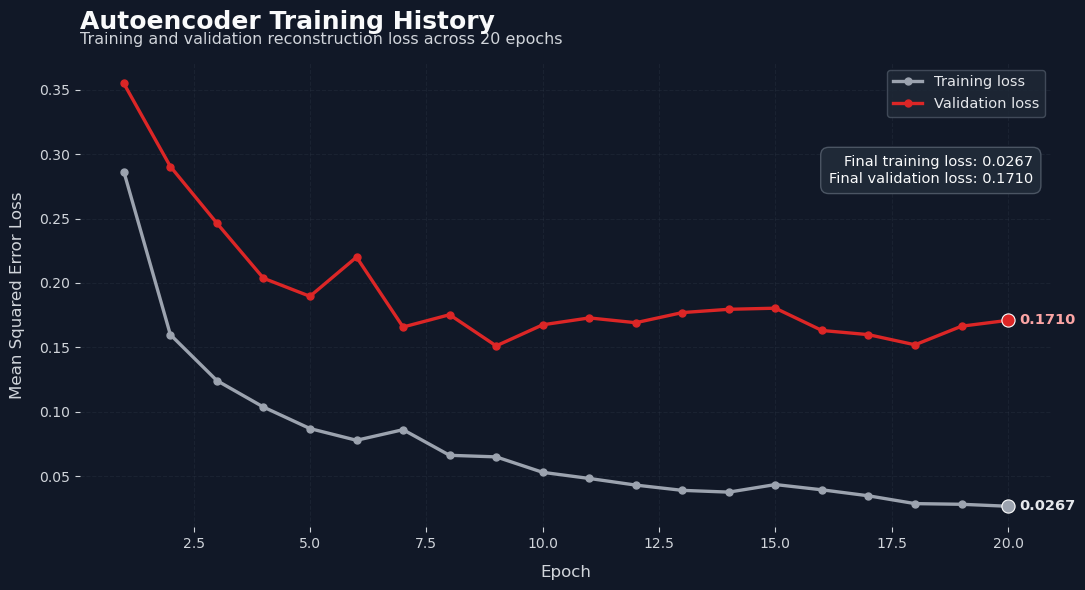

In [15]:
# ============================================================
# Step 8C: Professional chart - Autoencoder training history
# ============================================================
#
# Goal:
# Visualize how the Autoencoder loss changed during training.
#
# Variables used from previous steps:
#
# history:
# - Created in Step 8B when we trained the Autoencoder.
# - Contains training loss and validation loss for each epoch.
#
# history.history["loss"]:
# - Training reconstruction loss for each epoch.
#
# history.history["val_loss"]:
# - Validation reconstruction loss for each epoch.

import matplotlib.pyplot as plt
import pandas as pd

# ------------------------------------------------------------
# 1. Create a clean history dataframe
# ------------------------------------------------------------

training_history = pd.DataFrame({
    "epoch": range(1, len(history.history["loss"]) + 1),
    "training_loss": history.history["loss"],
    "validation_loss": history.history["val_loss"]
})

display(training_history.tail())

# ------------------------------------------------------------
# 2. Create professional dark-theme line chart
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 6))

# Dark corporate background
fig.patch.set_facecolor("#111827")
ax.set_facecolor("#111827")

# Plot training and validation loss
ax.plot(
    training_history["epoch"],
    training_history["training_loss"],
    marker="o",
    linewidth=2.4,
    markersize=5,
    color="#9CA3AF",
    label="Training loss"
)

ax.plot(
    training_history["epoch"],
    training_history["validation_loss"],
    marker="o",
    linewidth=2.4,
    markersize=5,
    color="#DC2626",
    label="Validation loss"
)

# ------------------------------------------------------------
# 3. Highlight final loss values
# ------------------------------------------------------------

final_epoch = training_history["epoch"].iloc[-1]
final_train_loss = training_history["training_loss"].iloc[-1]
final_val_loss = training_history["validation_loss"].iloc[-1]

ax.scatter(
    final_epoch,
    final_train_loss,
    s=90,
    color="#9CA3AF",
    edgecolor="white",
    linewidth=0.8,
    zorder=5
)

ax.scatter(
    final_epoch,
    final_val_loss,
    s=90,
    color="#DC2626",
    edgecolor="white",
    linewidth=0.8,
    zorder=5
)

ax.text(
    final_epoch + 0.25,
    final_train_loss,
    f"{final_train_loss:.4f}",
    va="center",
    fontsize=10.5,
    fontweight="bold",
    color="#E5E7EB"
)

ax.text(
    final_epoch + 0.25,
    final_val_loss,
    f"{final_val_loss:.4f}",
    va="center",
    fontsize=10.5,
    fontweight="bold",
    color="#FCA5A5"
)

# ------------------------------------------------------------
# 4. Titles and labels
# ------------------------------------------------------------

ax.set_title(
    "Autoencoder Training History",
    fontsize=18,
    fontweight="bold",
    loc="left",
    pad=24,
    color="#F9FAFB"
)

ax.text(
    0,
    1.04,
    "Training and validation reconstruction loss across 20 epochs",
    transform=ax.transAxes,
    fontsize=11.5,
    color="#D1D5DB"
)

ax.set_xlabel("Epoch", fontsize=12, labelpad=10, color="#D1D5DB")
ax.set_ylabel("Mean Squared Error Loss", fontsize=12, labelpad=10, color="#D1D5DB")

# ------------------------------------------------------------
# 5. Clean chart styling
# ------------------------------------------------------------

ax.grid(axis="both", linestyle="--", alpha=0.25, color="#374151")
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(axis="x", colors="#D1D5DB")
ax.tick_params(axis="y", colors="#D1D5DB")

legend = ax.legend(
    frameon=True,
    facecolor="#1F2937",
    edgecolor="#4B5563",
    fontsize=10.5
)

for text in legend.get_texts():
    text.set_color("#E5E7EB")

# Add insight box
ax.text(
    0.98,
    0.80,
    f"Final training loss: {final_train_loss:.4f}\nFinal validation loss: {final_val_loss:.4f}",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=10.5,
    color="#F9FAFB",
    bbox=dict(
        boxstyle="round,pad=0.55",
        facecolor="#1F2937",
        edgecolor="#4B5563"
    )
)

plt.tight_layout()
plt.show()

<div style="
background:#111827;
color:#e5e7eb;
border-radius:14px;
font-family:Arial, sans-serif;
line-height:1.6;
border:1px solid #374151;
overflow:hidden;
">

<div style="
background:#0b1220;
padding:18px 24px;
border-bottom:1px solid #374151;
">
<div style="
font-size:12px;
letter-spacing:1.2px;
text-transform:uppercase;
color:#9ca3af;
font-weight:700;
margin-bottom:6px;
">
Expert Section
</div>

<h2 style="
color:#f9fafb;
margin:0;
font-size:22px;
font-weight:800;
">
Step 8C Conclusion — Autoencoder Training History
</h2>
</div>

<div style="padding:24px;">

<p>
The training history chart shows how the Autoencoder reconstruction loss changed over 20 epochs.
</p>

<table style="width:100%; border-collapse:collapse; color:#e5e7eb; margin:18px 0;">
<tr>
<th style="text-align:left; padding:8px; border-bottom:1px solid #4b5563;">Metric</th>
<th style="text-align:left; padding:8px; border-bottom:1px solid #4b5563;">Final Value</th>
</tr>
<tr>
<td style="padding:8px;">Final training loss</td>
<td style="padding:8px;"><strong>0.0267</strong></td>
</tr>
<tr>
<td style="padding:8px;">Final validation loss</td>
<td style="padding:8px;"><strong>0.1710</strong></td>
</tr>
</table>

<p>
The training loss decreased strongly, which means the Autoencoder learned to reconstruct normal training traffic better over time.
</p>

<p>
The validation loss also decreased early, but later fluctuated. This means the model reconstructs validation rows less perfectly than the rows it trained on.
</p>

<div style="
background:#1f2937;
border-left:4px solid #9ca3af;
padding:15px 18px;
border-radius:10px;
margin-top:20px;
">
<strong style="color:#f3f4f6;">Interpretation:</strong><br>
The Autoencoder has learned normal traffic patterns. Next, we will calculate reconstruction error on the test set. Rows with high reconstruction error will be treated as possible anomalies.
</div>

</div>
</div>

<div style="
background:#111827;
color:#e5e7eb;
border-radius:14px;
font-family:Arial, sans-serif;
line-height:1.6;
border:1px solid #374151;
overflow:hidden;
">

<div style="
background:#0b1220;
padding:18px 24px;
border-bottom:1px solid #374151;
">
<div style="
font-size:12px;
letter-spacing:1.2px;
text-transform:uppercase;
color:#9ca3af;
font-weight:700;
margin-bottom:6px;
">
Expert Section
</div>

<h2 style="
color:#f9fafb;
margin:0;
font-size:22px;
font-weight:800;
">
Step 9 — Calculate Reconstruction Error
</h2>
</div>

<div style="padding:24px;">

<p>
Now we use the trained Autoencoder to reconstruct the test data.
</p>

<p>
The Autoencoder tries to rebuild each network connection from its compressed representation.
</p>

<p>
Then we calculate the difference between:
</p>

<ul>
<li>the original test row</li>
<li>the reconstructed test row</li>
</ul>

<div style="
background:#1f2937;
border-left:4px solid #9ca3af;
padding:15px 18px;
border-radius:10px;
margin-top:20px;
">
<strong style="color:#f3f4f6;">Core idea:</strong><br>
Low reconstruction error means the row looks normal.  
High reconstruction error means the row may be anomalous.
</div>

</div>
</div>

In [ ]:
# ============================================================
# Step 9A: Calculate reconstruction error on test data
# ============================================================
#
# Goal:
# Use the trained Autoencoder to reconstruct test rows.
# Then calculate reconstruction error for each row.
#
# Previous variables used:
#
# autoencoder:
# - trained neural network from Step 8B
#
# X_test_processed:
# - preprocessed test data from Step 6A
# - shape: 98,805 rows × 74 features
#
# y_test:
# - true test labels from Step 5A
# - 0 = normal
# - 1 = anomaly


# ------------------------------------------------------------
# 1. Reconstruct the test data
# ------------------------------------------------------------
#
# The Autoencoder receives the processed test data
# and tries to reconstruct it.
#
# Output shape should be the same as input:
# 98,805 rows × 74 features

X_test_reconstructed = autoencoder.predict(
    X_test_processed,
    verbose=0
)


# ------------------------------------------------------------
# 2. Calculate reconstruction error for each test row
# ------------------------------------------------------------

# For each row:
# reconstruction error = mean squared difference between
# original feature values and reconstructed feature values.
#
# Low error:
# - model reconstructed the row well
# - row likely looks normal
#
# High error:
# - model reconstructed the row poorly
# - row may be anomaly

test_reconstruction_error = np.mean(
    np.square(X_test_processed - X_test_reconstructed),
    axis=1
)


# ------------------------------------------------------------
# 3. Create result dataframe for analysis
# ------------------------------------------------------------

# This dataframe stores:
# - true label
# - readable connection type
# - reconstruction error

reconstruction_results = pd.DataFrame({
    "true_label": y_test,
    "connection_type": pd.Series(y_test).map({
        0: "Normal",
        1: "Anomaly"
    }),
    "reconstruction_error": test_reconstruction_error
})


# ------------------------------------------------------------
# 4. Summarize reconstruction error
# ------------------------------------------------------------

error_summary = (
    reconstruction_results
    .groupby("connection_type")["reconstruction_error"]
    .describe()
    .round(6)
)

print("Reconstruction error calculated successfully.")
print(f"Test rows scored: {len(reconstruction_results):,}")

display(error_summary)

print("\nTop 10 rows with highest reconstruction error:")
display(
    reconstruction_results
    .sort_values("reconstruction_error", ascending=False)
    .head(10)
)

Reconstruction error calculated successfully.
Test rows scored: 98,805


,count,mean,std,min,25%,50%,75%,max
connection_type,,,,,,,,
Anomaly,79349.0,1.979072,95.232368,0.016179,0.307519,0.307520,2.022151,26817.990234
Normal,19456.0,0.025770,0.725450,0.000331,0.001212,0.003227,0.010367,68.625465



Top 10 rows with highest reconstruction error:


,true_label,connection_type,reconstruction_error
33062,1,Anomaly,26817.990234
43101,1,Anomaly,120.683235
61430,1,Anomaly,119.757599
94744,1,Anomaly,119.056877
46358,1,Anomaly,106.065994
63735,1,Anomaly,103.311424
33305,1,Anomaly,92.240723
77638,1,Anomaly,74.054604
23906,0,Normal,68.625465
20912,1,Anomaly,66.095131


<div style="
background:#111827;
color:#e5e7eb;
border-radius:14px;
font-family:Arial, sans-serif;
line-height:1.6;
border:1px solid #374151;
overflow:hidden;
">

<div style="
background:#0b1220;
padding:18px 24px;
border-bottom:1px solid #374151;
">
<div style="
font-size:12px;
letter-spacing:1.2px;
text-transform:uppercase;
color:#9ca3af;
font-weight:700;
margin-bottom:6px;
">
Expert Section
</div>

<h2 style="
color:#f9fafb;
margin:0;
font-size:22px;
font-weight:800;
">
Step 9A Conclusion — Reconstruction Error Calculated
</h2>
</div>

<div style="padding:24px;">

<p>
The trained Autoencoder was used to reconstruct the test data.
</p>

<p>
Then reconstruction error was calculated for each test row.
</p>

<table style="width:100%; border-collapse:collapse; color:#e5e7eb; margin:18px 0;">
<tr>
<th style="text-align:left; padding:8px; border-bottom:1px solid #4b5563;">Connection Type</th>
<th style="text-align:left; padding:8px; border-bottom:1px solid #4b5563;">Rows</th>
<th style="text-align:left; padding:8px; border-bottom:1px solid #4b5563;">Median Error</th>
<th style="text-align:left; padding:8px; border-bottom:1px solid #4b5563;">Mean Error</th>
</tr>
<tr>
<td style="padding:8px;">Normal</td>
<td style="padding:8px;"><strong>19,456</strong></td>
<td style="padding:8px;"><strong>0.003227</strong></td>
<td style="padding:8px;"><strong>0.025770</strong></td>
</tr>
<tr>
<td style="padding:8px;">Anomaly</td>
<td style="padding:8px;"><strong>79,349</strong></td>
<td style="padding:8px;"><strong>0.307520</strong></td>
<td style="padding:8px;"><strong>1.979072</strong></td>
</tr>
</table>

<p>
Normal connections generally have much lower reconstruction error than anomaly connections.
</p>

<p>
This is a good sign because the Autoencoder was trained on normal traffic and is now reconstructing normal rows better than attack rows.
</p>

<div style="
background:#1f2937;
border-left:4px solid #9ca3af;
padding:15px 18px;
border-radius:10px;
margin-top:20px;
">
<strong style="color:#f3f4f6;">Key idea:</strong><br>
Reconstruction error is now our anomaly score. Higher reconstruction error means the connection is more suspicious.
</div>

</div>
</div>

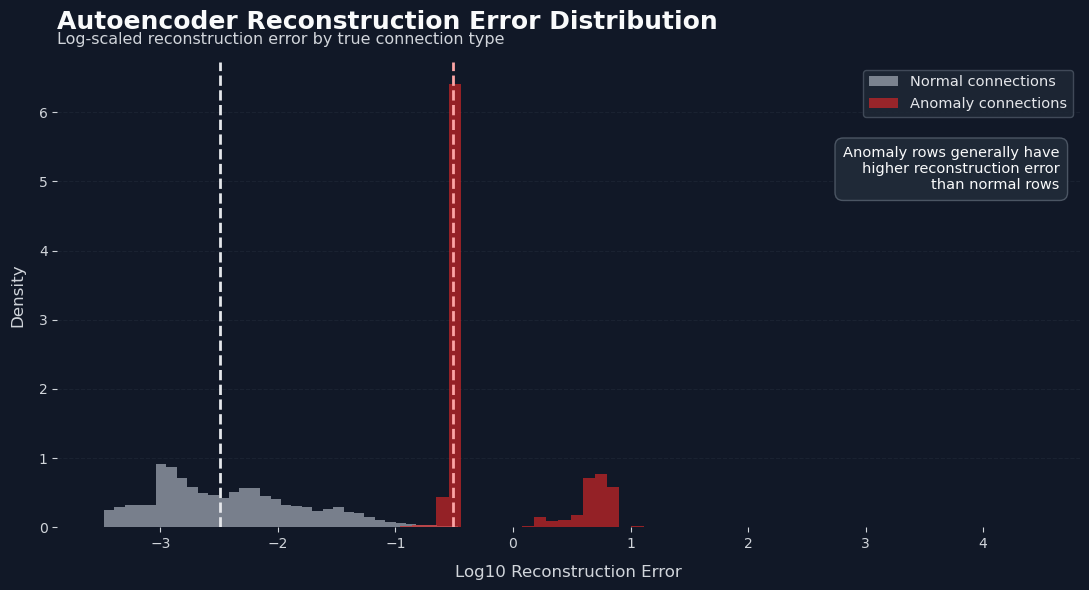

In [17]:
# ============================================================
# Step 9B: Reconstruction error distribution
# ============================================================
#
# Goal:
# Visualize how reconstruction error differs between normal and anomaly rows.
#
# Why log scale?
# Reconstruction error has some very large extreme values.
# A normal histogram would be dominated by those extreme values.
# Log scale makes the distribution easier to read.
#
# Previous variables used:
#
# reconstruction_results:
# - Created in Step 9A.
# - Contains:
#   - true_label
#   - connection_type
#   - reconstruction_error

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Create log reconstruction error
# ------------------------------------------------------------
#
# We add a very small number before log transformation
# to avoid problems if any reconstruction error is exactly zero.

reconstruction_results["log_reconstruction_error"] = np.log10(
    reconstruction_results["reconstruction_error"] + 1e-8
)

# Split normal and anomaly rows
normal_errors = reconstruction_results.loc[
    reconstruction_results["connection_type"] == "Normal",
    "log_reconstruction_error"
]

anomaly_errors = reconstruction_results.loc[
    reconstruction_results["connection_type"] == "Anomaly",
    "log_reconstruction_error"
]

# ------------------------------------------------------------
# 2. Create dark corporate histogram
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 6))

fig.patch.set_facecolor("#111827")
ax.set_facecolor("#111827")

# Histogram for normal rows
ax.hist(
    normal_errors,
    bins=60,
    alpha=0.75,
    color="#9CA3AF",
    label="Normal connections",
    density=True
)

# Histogram for anomaly rows
ax.hist(
    anomaly_errors,
    bins=60,
    alpha=0.65,
    color="#DC2626",
    label="Anomaly connections",
    density=True
)

# ------------------------------------------------------------
# 3. Add median lines
# ------------------------------------------------------------

normal_median_log = np.median(normal_errors)
anomaly_median_log = np.median(anomaly_errors)

ax.axvline(
    normal_median_log,
    color="#E5E7EB",
    linestyle="--",
    linewidth=2
)

ax.axvline(
    anomaly_median_log,
    color="#FCA5A5",
    linestyle="--",
    linewidth=2
)

# ------------------------------------------------------------
# 4. Titles and labels
# ------------------------------------------------------------

ax.set_title(
    "Autoencoder Reconstruction Error Distribution",
    fontsize=18,
    fontweight="bold",
    loc="left",
    pad=24,
    color="#F9FAFB"
)

ax.text(
    0,
    1.04,
    "Log-scaled reconstruction error by true connection type",
    transform=ax.transAxes,
    fontsize=11.5,
    color="#D1D5DB"
)

ax.set_xlabel(
    "Log10 Reconstruction Error",
    fontsize=12,
    labelpad=10,
    color="#D1D5DB"
)

ax.set_ylabel(
    "Density",
    fontsize=12,
    labelpad=10,
    color="#D1D5DB"
)

# ------------------------------------------------------------
# 5. Styling
# ------------------------------------------------------------

ax.grid(axis="y", linestyle="--", alpha=0.25, color="#374151")
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(axis="x", colors="#D1D5DB")
ax.tick_params(axis="y", colors="#D1D5DB")

legend = ax.legend(
    frameon=True,
    facecolor="#1F2937",
    edgecolor="#4B5563",
    fontsize=10.5
)

for text in legend.get_texts():
    text.set_color("#E5E7EB")

# Insight box
ax.text(
    0.98,
    0.82,
    "Anomaly rows generally have\nhigher reconstruction error\nthan normal rows",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=10.5,
    color="#F9FAFB",
    bbox=dict(
        boxstyle="round,pad=0.55",
        facecolor="#1F2937",
        edgecolor="#4B5563"
    )
)

plt.tight_layout()
plt.show()

<div style="
background:#111827;
color:#e5e7eb;
border-radius:14px;
font-family:Arial, sans-serif;
line-height:1.6;
border:1px solid #374151;
overflow:hidden;
">

<div style="
background:#0b1220;
padding:18px 24px;
border-bottom:1px solid #374151;
">
<div style="
font-size:12px;
letter-spacing:1.2px;
text-transform:uppercase;
color:#9ca3af;
font-weight:700;
margin-bottom:6px;
">
Expert Section
</div>

<h2 style="
color:#f9fafb;
margin:0;
font-size:22px;
font-weight:800;
">
Step 9B Conclusion — Reconstruction Error Distribution
</h2>
</div>

<div style="padding:24px;">

<p>
The reconstruction error distribution shows a clear difference between normal and anomaly connections.
</p>

<p>
Normal connections mostly have lower reconstruction error, while anomaly connections generally have higher reconstruction error.
</p>

<table style="width:100%; border-collapse:collapse; color:#e5e7eb; margin:18px 0;">
<tr>
<th style="text-align:left; padding:8px; border-bottom:1px solid #4b5563;">Connection Type</th>
<th style="text-align:left; padding:8px; border-bottom:1px solid #4b5563;">Typical Pattern</th>
</tr>
<tr>
<td style="padding:8px;">Normal</td>
<td style="padding:8px;">Lower reconstruction error</td>
</tr>
<tr>
<td style="padding:8px;">Anomaly</td>
<td style="padding:8px;">Higher reconstruction error</td>
</tr>
</table>

<p>
The chart uses a log scale because reconstruction errors contain some extreme values.
</p>

<p>
This makes the separation between normal and anomaly records easier to see.
</p>

<div style="
background:#1f2937;
border-left:4px solid #9ca3af;
padding:15px 18px;
border-radius:10px;
margin-top:20px;
">
<strong style="color:#f3f4f6;">Key interpretation:</strong><br>
The Autoencoder is producing higher reconstruction errors for attack-like connections. This means reconstruction error can be used as an anomaly score.
</div>

</div>
</div>

<div style="
background:#111827;
color:#e5e7eb;
border-radius:14px;
font-family:Arial, sans-serif;
line-height:1.6;
border:1px solid #374151;
overflow:hidden;
">

<div style="
background:#0b1220;
padding:18px 24px;
border-bottom:1px solid #374151;
">
<div style="
font-size:12px;
letter-spacing:1.2px;
text-transform:uppercase;
color:#9ca3af;
font-weight:700;
margin-bottom:6px;
">
Expert Section
</div>

<h2 style="
color:#f9fafb;
margin:0;
font-size:22px;
font-weight:800;
">
Step 10 — Choose Anomaly Threshold
</h2>
</div>

<div style="padding:24px;">

<p>
The Autoencoder gives each network connection a reconstruction error.
</p>

<p>
Now we choose a threshold to convert reconstruction error into a final prediction.
</p>

<ul>
<li>Low reconstruction error = likely normal</li>
<li>High reconstruction error = likely anomaly</li>
</ul>

<div style="
background:#1f2937;
border-left:4px solid #9ca3af;
padding:15px 18px;
border-radius:10px;
margin-top:20px;
">
<strong style="color:#f3f4f6;">Threshold strategy:</strong><br>
We calculate reconstruction errors on normal training data and use the 95th percentile as the threshold.
</div>

<p>
This means that most normal training rows are accepted as normal, while rows with unusually high reconstruction error are flagged as anomalies.
</p>

</div>
</div>

In [ ]:
# ============================================================
# Step 10A: Choose anomaly threshold from normal training data
# ============================================================
#
# Goal:
# Choose a reconstruction error threshold.
#
# Previous variables used:
#
# autoencoder:
# - Trained Autoencoder model from Step 8B
#
# X_train_normal_processed:
# - Normal training rows only
# - Shape: 77,822 rows × 74 features
#
# reconstruction_results:
# - Test reconstruction errors from Step 9A
#
# Why use normal training data?
# The Autoencoder was trained to reconstruct normal traffic.
# So we calculate the normal reconstruction error range first.
#
# Threshold logic:
# Use the 95th percentile of normal training reconstruction errors.
#
# This means:
# - 95% of normal training rows have error below this threshold
# - rows above this threshold are treated as suspicious


# ------------------------------------------------------------
# 1. Reconstruct normal training rows
# ------------------------------------------------------------

X_train_normal_reconstructed = autoencoder.predict(
    X_train_normal_processed,
    verbose=0
)


# ------------------------------------------------------------
# 2. Calculate reconstruction error for normal training rows
# ------------------------------------------------------------
#
# For each normal training row:
# error = average squared difference between original and reconstructed values

train_normal_reconstruction_error = np.mean(
    np.square(X_train_normal_processed - X_train_normal_reconstructed),
    axis=1
)


# ------------------------------------------------------------
# 3. Choose threshold using 95th percentile
# ------------------------------------------------------------
#
# Percentile explanation:
#
# If threshold = 95th percentile,
# only the top 5% highest normal training errors are above the threshold.
#
# This is a common starting point for anomaly detection.

anomaly_threshold = np.percentile(
    train_normal_reconstruction_error,
    95
)


# ------------------------------------------------------------
# 4. Apply threshold to test reconstruction errors
# ------------------------------------------------------------

# If test reconstruction error is greater than threshold:
# predict anomaly = 1
#
# Otherwise:
# predict normal = 0

reconstruction_results["predicted_label"] = (
    reconstruction_results["reconstruction_error"] > anomaly_threshold
).astype(int)

reconstruction_results["predicted_type"] = (
    reconstruction_results["predicted_label"]
    .map({
        0: "Predicted Normal",
        1: "Predicted Anomaly"
    })
)


# ------------------------------------------------------------
# 5. Summarize threshold and predictions
# ------------------------------------------------------------

prediction_summary = (
    reconstruction_results["predicted_type"]
    .value_counts()
    .reset_index()
)

prediction_summary.columns = ["prediction", "row_count"]

prediction_summary["percentage"] = (
    prediction_summary["row_count"] / len(reconstruction_results) * 100
).round(2)

print("Anomaly threshold selected successfully.")
print(f"Threshold method: 95th percentile of normal training reconstruction error")
print(f"Anomaly threshold: {anomaly_threshold:.6f}")

display(prediction_summary)

Anomaly threshold selected successfully.
Threshold method: 95th percentile of normal training reconstruction error
Anomaly threshold: 0.056505


,prediction,row_count,percentage
0,Predicted Anomaly,80198,81.17
1,Predicted Normal,18607,18.83


<div style="
background:#111827;
color:#e5e7eb;
border-radius:14px;
font-family:Arial, sans-serif;
line-height:1.6;
border:1px solid #374151;
overflow:hidden;
">

<div style="
background:#0b1220;
padding:18px 24px;
border-bottom:1px solid #374151;
">
<div style="
font-size:12px;
letter-spacing:1.2px;
text-transform:uppercase;
color:#9ca3af;
font-weight:700;
margin-bottom:6px;
">
Expert Section
</div>

<h2 style="
color:#f9fafb;
margin:0;
font-size:22px;
font-weight:800;
">
Step 10A Conclusion — Anomaly Threshold Applied
</h2>
</div>

<div style="padding:24px;">

<p>
The anomaly threshold was selected using the 95th percentile of normal training reconstruction errors.
</p>

<p>
Rows with reconstruction error greater than the threshold were predicted as anomalies.
</p>

<table style="width:100%; border-collapse:collapse; color:#e5e7eb; margin:18px 0;">
<tr>
<th style="text-align:left; padding:8px; border-bottom:1px solid #4b5563;">Prediction</th>
<th style="text-align:left; padding:8px; border-bottom:1px solid #4b5563;">Rows</th>
<th style="text-align:left; padding:8px; border-bottom:1px solid #4b5563;">Percentage</th>
</tr>
<tr>
<td style="padding:8px;">Predicted Anomaly</td>
<td style="padding:8px;"><strong>80,198</strong></td>
<td style="padding:8px;"><strong>81.17%</strong></td>
</tr>
<tr>
<td style="padding:8px;">Predicted Normal</td>
<td style="padding:8px;"><strong>18,607</strong></td>
<td style="padding:8px;"><strong>18.83%</strong></td>
</tr>
</table>

<p>
The predicted distribution is close to the actual Normal vs Anomaly distribution in the test set.
</p>

<div style="
background:#1f2937;
border-left:4px solid #9ca3af;
padding:15px 18px;
border-radius:10px;
margin-top:20px;
">
<strong style="color:#f3f4f6;">Key idea:</strong><br>
The threshold converts reconstruction error into final anomaly predictions. The next step is to evaluate these predictions against the true test labels.
</div>

</div>
</div>

<div style="
background:#111827;
color:#e5e7eb;
border-radius:14px;
font-family:Arial, sans-serif;
line-height:1.6;
border:1px solid #374151;
overflow:hidden;
">

<div style="
background:#0b1220;
padding:18px 24px;
border-bottom:1px solid #374151;
">
<div style="
font-size:12px;
letter-spacing:1.2px;
text-transform:uppercase;
color:#9ca3af;
font-weight:700;
margin-bottom:6px;
">
Expert Section
</div>

<h2 style="
color:#f9fafb;
margin:0;
font-size:22px;
font-weight:800;
">
Step 11 — Evaluate Autoencoder Predictions
</h2>
</div>

<div style="padding:24px;">

<p>
Now we evaluate how well the Autoencoder detected anomalies.
</p>

<p>
We compare the predicted labels with the true test labels.
</p>

<table style="width:100%; border-collapse:collapse; color:#e5e7eb; margin:18px 0;">
<tr>
<th style="text-align:left; padding:8px; border-bottom:1px solid #4b5563;">Metric</th>
<th style="text-align:left; padding:8px; border-bottom:1px solid #4b5563;">Meaning</th>
</tr>
<tr>
<td style="padding:8px;">Precision</td>
<td style="padding:8px;">Of the rows predicted as anomaly, how many were truly anomaly?</td>
</tr>
<tr>
<td style="padding:8px;">Recall</td>
<td style="padding:8px;">Of all true anomaly rows, how many did the model catch?</td>
</tr>
<tr>
<td style="padding:8px;">F1-score</td>
<td style="padding:8px;">Balanced score between precision and recall.</td>
</tr>
</table>

<div style="
background:#1f2937;
border-left:4px solid #9ca3af;
padding:15px 18px;
border-radius:10px;
margin-top:20px;
">
<strong style="color:#f3f4f6;">Goal of this step:</strong><br>
Measure whether reconstruction error is useful for detecting attack-like network connections.
</div>

</div>
</div>

In [19]:
# ============================================================
# Step 11A: Evaluate Autoencoder anomaly detection performance
# ============================================================
#
# Goal:
# Compare Autoencoder predictions with the true test labels.
#
# Previous variables used:
#
# y_test:
# - Created in Step 5A.
# - True labels for test data.
# - 0 = normal
# - 1 = anomaly
#
# reconstruction_results:
# - Created in Step 9A and updated in Step 10A.
# - Contains:
#   - true_label
#   - connection_type
#   - reconstruction_error
#   - predicted_label
#   - predicted_type
#
# predicted_label:
# - Created in Step 10A.
# - 0 = predicted normal
# - 1 = predicted anomaly

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix,
    classification_report
)

# ------------------------------------------------------------
# 1. Prepare true labels and predicted labels
# ------------------------------------------------------------

# True labels from the test set
y_true_autoencoder = reconstruction_results["true_label"].astype(int)

# Predicted labels from reconstruction error threshold
y_pred_autoencoder = reconstruction_results["predicted_label"].astype(int)


# ------------------------------------------------------------
# 2. Calculate evaluation metrics
# ------------------------------------------------------------
#
# Precision:
# Of all rows predicted as anomaly, how many were truly anomaly?
#
# Recall:
# Of all true anomaly rows, how many did the model catch?
#
# F1-score:
# Balanced score between precision and recall.
#
# Accuracy:
# Overall percentage of correct predictions.
# Be careful with accuracy in imbalanced datasets.

autoencoder_precision = precision_score(
    y_true_autoencoder,
    y_pred_autoencoder,
    zero_division=0
)

autoencoder_recall = recall_score(
    y_true_autoencoder,
    y_pred_autoencoder,
    zero_division=0
)

autoencoder_f1 = f1_score(
    y_true_autoencoder,
    y_pred_autoencoder,
    zero_division=0
)

autoencoder_accuracy = accuracy_score(
    y_true_autoencoder,
    y_pred_autoencoder
)


# ------------------------------------------------------------
# 3. Create metrics summary table
# ------------------------------------------------------------

autoencoder_metrics = pd.DataFrame({
    "model": ["Autoencoder"],
    "precision": [round(autoencoder_precision, 4)],
    "recall": [round(autoencoder_recall, 4)],
    "f1_score": [round(autoencoder_f1, 4)],
    "accuracy": [round(autoencoder_accuracy, 4)]
})

print("Autoencoder evaluation completed.")
display(autoencoder_metrics)


# ------------------------------------------------------------
# 4. Create confusion matrix
# ------------------------------------------------------------
#
# Confusion matrix layout:
#
# [[True Normal predicted Normal, True Normal predicted Anomaly],
#  [True Anomaly predicted Normal, True Anomaly predicted Anomaly]]
#
# In business terms:
#
# True Normal predicted Anomaly = false alarm
# True Anomaly predicted Normal = missed attack

cm_autoencoder = confusion_matrix(
    y_true_autoencoder,
    y_pred_autoencoder
)

confusion_matrix_table = pd.DataFrame(
    cm_autoencoder,
    index=["Actual Normal", "Actual Anomaly"],
    columns=["Predicted Normal", "Predicted Anomaly"]
)

print("Confusion matrix:")
display(confusion_matrix_table)


# ------------------------------------------------------------
# 5. Print detailed classification report
# ------------------------------------------------------------

print("Classification report:")
print(
    classification_report(
        y_true_autoencoder,
        y_pred_autoencoder,
        target_names=["Normal", "Anomaly"],
        zero_division=0
    )
)

Autoencoder evaluation completed.


,model,precision,recall,f1_score,accuracy
0,Autoencoder,0.9879,0.9984,0.9931,0.9889


Confusion matrix:


,Predicted Normal,Predicted Anomaly
Actual Normal,18482,974
Actual Anomaly,125,79224


Classification report:
              precision    recall  f1-score   support

      Normal       0.99      0.95      0.97     19456
     Anomaly       0.99      1.00      0.99     79349

    accuracy                           0.99     98805
   macro avg       0.99      0.97      0.98     98805
weighted avg       0.99      0.99      0.99     98805



<div style="
background:#111827;
color:#e5e7eb;
border-radius:14px;
font-family:Arial, sans-serif;
line-height:1.6;
border:1px solid #374151;
overflow:hidden;
">

<div style="
background:#0b1220;
padding:18px 24px;
border-bottom:1px solid #374151;
">
<div style="
font-size:12px;
letter-spacing:1.2px;
text-transform:uppercase;
color:#9ca3af;
font-weight:700;
margin-bottom:6px;
">
Expert Section
</div>

<h2 style="
color:#f9fafb;
margin:0;
font-size:22px;
font-weight:800;
">
Step 11A Conclusion — Autoencoder Evaluation Completed
</h2>
</div>

<div style="padding:24px;">

<p>
The Autoencoder predictions were evaluated against the true test labels.
</p>

<table style="width:100%; border-collapse:collapse; color:#e5e7eb; margin:18px 0;">
<tr>
<th style="text-align:left; padding:8px; border-bottom:1px solid #4b5563;">Metric</th>
<th style="text-align:left; padding:8px; border-bottom:1px solid #4b5563;">Value</th>
<th style="text-align:left; padding:8px; border-bottom:1px solid #4b5563;">Interpretation</th>
</tr>
<tr>
<td style="padding:8px;">Precision</td>
<td style="padding:8px;"><strong>0.9879</strong></td>
<td style="padding:8px;">Most rows predicted as anomaly were truly anomaly.</td>
</tr>
<tr>
<td style="padding:8px;">Recall</td>
<td style="padding:8px;"><strong>0.9984</strong></td>
<td style="padding:8px;">The model caught almost all actual anomaly rows.</td>
</tr>
<tr>
<td style="padding:8px;">F1-score</td>
<td style="padding:8px;"><strong>0.9931</strong></td>
<td style="padding:8px;">Very strong balance between precision and recall.</td>
</tr>
<tr>
<td style="padding:8px;">Accuracy</td>
<td style="padding:8px;"><strong>0.9889</strong></td>
<td style="padding:8px;">Most total predictions were correct.</td>
</tr>
</table>

<h3 style="color:#f3f4f6;">Confusion Matrix Interpretation</h3>

<table style="width:100%; border-collapse:collapse; color:#e5e7eb; margin:18px 0;">
<tr>
<th style="text-align:left; padding:8px; border-bottom:1px solid #4b5563;">Outcome</th>
<th style="text-align:left; padding:8px; border-bottom:1px solid #4b5563;">Rows</th>
<th style="text-align:left; padding:8px; border-bottom:1px solid #4b5563;">Meaning</th>
</tr>
<tr>
<td style="padding:8px;">Actual Normal → Predicted Normal</td>
<td style="padding:8px;"><strong>18,482</strong></td>
<td style="padding:8px;">Correctly identified normal traffic.</td>
</tr>
<tr>
<td style="padding:8px;">Actual Normal → Predicted Anomaly</td>
<td style="padding:8px;"><strong>974</strong></td>
<td style="padding:8px;">False alarms.</td>
</tr>
<tr>
<td style="padding:8px;">Actual Anomaly → Predicted Normal</td>
<td style="padding:8px;"><strong>125</strong></td>
<td style="padding:8px;">Missed attacks.</td>
</tr>
<tr>
<td style="padding:8px;">Actual Anomaly → Predicted Anomaly</td>
<td style="padding:8px;"><strong>79,224</strong></td>
<td style="padding:8px;">Correctly detected attacks.</td>
</tr>
</table>

<div style="
background:#1f2937;
border-left:4px solid #9ca3af;
padding:15px 18px;
border-radius:10px;
margin-top:20px;
">
<strong style="color:#f3f4f6;">Key interpretation:</strong><br>
The Autoencoder performed very well on this test set. It detected almost all attack-like connections, with only 125 missed anomaly rows.
</div>

</div>
</div>

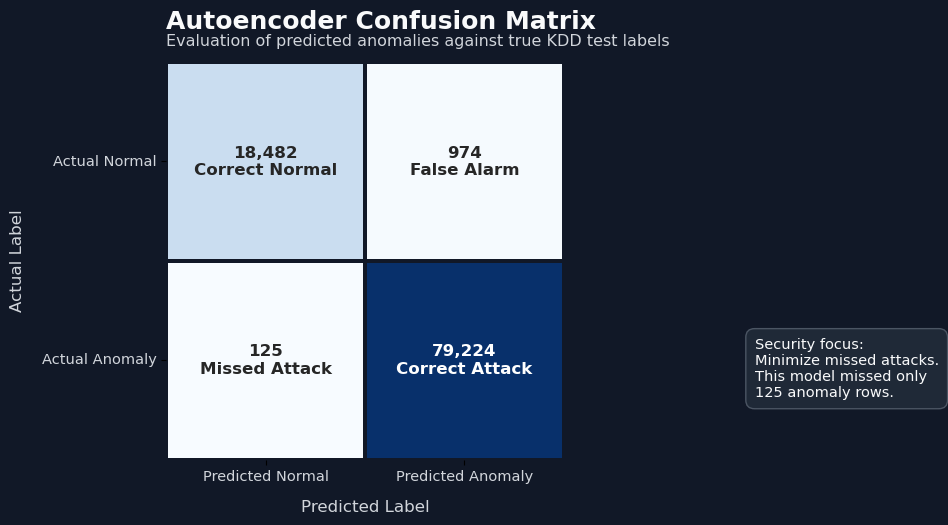

In [20]:
# ============================================================
# Step 11B: Professional chart - Autoencoder confusion matrix
# ============================================================
#
# Goal:
# Visualize correct and incorrect Autoencoder predictions.
#
# Previous variables used:
#
# confusion_matrix_table:
# - Created in Step 11A.
# - Shows actual vs predicted labels.
#
# cm_autoencoder:
# - Raw confusion matrix array from Step 11A.
#
# Confusion matrix layout:
#
# Actual Normal  → Predicted Normal   = correct normal
# Actual Normal  → Predicted Anomaly  = false alarm
# Actual Anomaly → Predicted Normal   = missed attack
# Actual Anomaly → Predicted Anomaly  = correct attack detection

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ------------------------------------------------------------
# 1. Create labels for the heatmap
# ------------------------------------------------------------

cm_labels = np.array([
    [f"{cm_autoencoder[0, 0]:,}\nCorrect Normal", f"{cm_autoencoder[0, 1]:,}\nFalse Alarm"],
    [f"{cm_autoencoder[1, 0]:,}\nMissed Attack", f"{cm_autoencoder[1, 1]:,}\nCorrect Attack"]
])

# ------------------------------------------------------------
# 2. Create dark corporate confusion matrix heatmap
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(8.5, 6.5))

fig.patch.set_facecolor("#111827")
ax.set_facecolor("#111827")

sns.heatmap(
    cm_autoencoder,
    annot=cm_labels,
    fmt="",
    cmap="Blues",
    cbar=False,
    linewidths=1.5,
    linecolor="#111827",
    square=True,
    annot_kws={
        "fontsize": 12,
        "fontweight": "bold"
    },
    ax=ax
)

# ------------------------------------------------------------
# 3. Titles and labels
# ------------------------------------------------------------

ax.set_title(
    "Autoencoder Confusion Matrix",
    fontsize=18,
    fontweight="bold",
    loc="left",
    pad=24,
    color="#F9FAFB"
)

ax.text(
    0,
    1.04,
    "Evaluation of predicted anomalies against true KDD test labels",
    transform=ax.transAxes,
    fontsize=11.5,
    color="#D1D5DB"
)

ax.set_xlabel(
    "Predicted Label",
    fontsize=12,
    labelpad=12,
    color="#D1D5DB"
)

ax.set_ylabel(
    "Actual Label",
    fontsize=12,
    labelpad=12,
    color="#D1D5DB"
)

ax.set_xticklabels(
    ["Predicted Normal", "Predicted Anomaly"],
    fontsize=10.5,
    color="#D1D5DB"
)

ax.set_yticklabels(
    ["Actual Normal", "Actual Anomaly"],
    fontsize=10.5,
    color="#D1D5DB",
    rotation=0
)

# ------------------------------------------------------------
# 4. Add business interpretation box
# ------------------------------------------------------------

ax.text(
    1.48,
    0.15,
    "Security focus:\nMinimize missed attacks.\nThis model missed only\n125 anomaly rows.",
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    fontsize=10.5,
    color="#F9FAFB",
    bbox=dict(
        boxstyle="round,pad=0.6",
        facecolor="#1F2937",
        edgecolor="#4B5563"
    )
)

plt.tight_layout()
plt.show()

<div style="
background:#111827;
color:#e5e7eb;
border-radius:14px;
font-family:Arial, sans-serif;
line-height:1.6;
border:1px solid #374151;
overflow:hidden;
">

<div style="
background:#0b1220;
padding:18px 24px;
border-bottom:1px solid #374151;
">
<div style="
font-size:12px;
letter-spacing:1.2px;
text-transform:uppercase;
color:#9ca3af;
font-weight:700;
margin-bottom:6px;
">
Expert Section
</div>

<h2 style="
color:#f9fafb;
margin:0;
font-size:22px;
font-weight:800;
">
Step 11B Conclusion — Confusion Matrix Interpretation
</h2>
</div>

<div style="padding:24px;">

<p>
The confusion matrix shows how the Autoencoder predictions compare with the true KDD test labels.
</p>

<table style="width:100%; border-collapse:collapse; color:#e5e7eb; margin:18px 0;">
<tr>
<th style="text-align:left; padding:8px; border-bottom:1px solid #4b5563;">Outcome</th>
<th style="text-align:left; padding:8px; border-bottom:1px solid #4b5563;">Rows</th>
<th style="text-align:left; padding:8px; border-bottom:1px solid #4b5563;">Meaning</th>
</tr>
<tr>
<td style="padding:8px;">Correct Normal</td>
<td style="padding:8px;"><strong>18,482</strong></td>
<td style="padding:8px;">Normal connections correctly predicted as normal.</td>
</tr>
<tr>
<td style="padding:8px;">False Alarm</td>
<td style="padding:8px;"><strong>974</strong></td>
<td style="padding:8px;">Normal connections incorrectly flagged as anomalies.</td>
</tr>
<tr>
<td style="padding:8px;">Missed Attack</td>
<td style="padding:8px;"><strong>125</strong></td>
<td style="padding:8px;">Attack/anomaly connections incorrectly predicted as normal.</td>
</tr>
<tr>
<td style="padding:8px;">Correct Attack</td>
<td style="padding:8px;"><strong>79,224</strong></td>
<td style="padding:8px;">Attack/anomaly connections correctly detected.</td>
</tr>
</table>

<p>
The most important security risk is the <strong>Missed Attack</strong> category.
</p>

<p>
The Autoencoder missed only <strong>125 anomaly rows</strong> out of <strong>79,349 actual anomaly rows</strong>.
</p>

<div style="
background:#1f2937;
border-left:4px solid #9ca3af;
padding:15px 18px;
border-radius:10px;
margin-top:20px;
">
<strong style="color:#f3f4f6;">Business interpretation:</strong><br>
The Autoencoder is highly effective at detecting attack-like network behavior. It catches almost all anomaly rows while keeping false alarms relatively low.
</div>

</div>
</div>

Train Isolation Forest on normal training rows only
↓
Calculate anomaly scores
↓
Use 95th percentile of normal training scores as threshold
↓
Predict test rows as normal or anomaly

<div style="
background:#111827;
color:#e5e7eb;
border-radius:14px;
font-family:Arial, sans-serif;
line-height:1.6;
border:1px solid #374151;
overflow:hidden;
">

<div style="
background:#0b1220;
padding:18px 24px;
border-bottom:1px solid #374151;
">
<div style="
font-size:12px;
letter-spacing:1.2px;
text-transform:uppercase;
color:#9ca3af;
font-weight:700;
margin-bottom:6px;
">
Expert Section
</div>

<h2 style="
color:#f9fafb;
margin:0;
font-size:22px;
font-weight:800;
">
Step 12 — Isolation Forest Baseline on KDD Data
</h2>
</div>

<div style="padding:24px;">

<p>
Now we create an Isolation Forest baseline using the same processed KDD features.
</p>

<p>
To make the comparison fair, Isolation Forest will also learn from normal training rows only.
</p>

<div style="
background:#1f2937;
border-left:4px solid #9ca3af;
padding:15px 18px;
border-radius:10px;
margin:20px 0;
">
<strong style="color:#f3f4f6;">Comparison idea:</strong><br>
Autoencoder and Isolation Forest both learn from normal traffic first. Then both are evaluated on the same test set.
</div>

<p>
This helps us compare a neural-network anomaly method against a traditional tree-based anomaly method.
</p>

To make the comparison fair, Isolation Forest will also learn from normal training rows only.


<p>Train Isolation Forest on normal training rows only</p>
            ↓
<p>Calculate anomaly scores</p>
            ↓
<p>Use 95th percentile of normal training scores as threshold</p>
            ↓
<p>Predict test rows as normal or anomaly</p>

</div>
</div>

In [21]:
# ============================================================
# Step 12A: Train Isolation Forest baseline on normal KDD traffic
# ============================================================
#
# Goal:
# Create a traditional anomaly detection baseline and compare it later
# with the Autoencoder.
#
# Why train on normal rows only?
# The Autoencoder learned normal traffic only.
# To make the comparison fair, Isolation Forest will also learn from
# normal training rows only.
#
# Previous variables used:
#
# X_train_normal_processed:
# - Created in Step 6A.
# - Processed normal training rows.
# - Shape: 77,822 rows × 74 features.
#
# X_test_processed:
# - Created in Step 6A.
# - Processed test data.
# - Shape: 98,805 rows × 74 features.
#
# reconstruction_results:
# - Created in Step 9A and updated in Step 10A.
# - Already contains Autoencoder predictions.
#
# y_test:
# - True test labels.
# - 0 = normal
# - 1 = anomaly

from sklearn.ensemble import IsolationForest

# ------------------------------------------------------------
# 1. Create Isolation Forest model
# ------------------------------------------------------------
#
# Isolation Forest idea:
# - unusual rows are easier to isolate
# - normal rows need more splits to isolate
#
# We use contamination="auto" because we will define our own threshold
# using normal training scores.

isolation_forest_kdd = IsolationForest(
    n_estimators=100,
    contamination="auto",
    random_state=RANDOM_STATE,
    n_jobs=-1
)


# ------------------------------------------------------------
# 2. Train Isolation Forest on normal training rows only
# ------------------------------------------------------------
#
# The model learns the structure of normal network traffic.

isolation_forest_kdd.fit(X_train_normal_processed)


# ------------------------------------------------------------
# 3. Calculate anomaly scores for normal training data
# ------------------------------------------------------------
#
# score_samples() returns higher scores for more normal rows.
#
# For easier interpretation, we multiply by -1:
#
# higher anomaly_score = more suspicious

train_normal_if_scores = -isolation_forest_kdd.score_samples(
    X_train_normal_processed
)


# ------------------------------------------------------------
# 4. Choose threshold from normal training scores
# ------------------------------------------------------------
#
# We use the 95th percentile again.
#
# This means:
# - 95% of normal training rows are accepted as normal
# - top 5% highest normal training scores define suspicious behavior

if_threshold = np.percentile(
    train_normal_if_scores,
    95
)


# ------------------------------------------------------------
# 5. Calculate anomaly scores for test data
# ------------------------------------------------------------

test_if_scores = -isolation_forest_kdd.score_samples(
    X_test_processed
)


# ------------------------------------------------------------
# 6. Convert scores into predictions
# ------------------------------------------------------------
#
# If score > threshold:
# predicted anomaly = 1
#
# Else:
# predicted normal = 0

reconstruction_results["if_anomaly_score"] = test_if_scores

reconstruction_results["if_predicted_label"] = (
    reconstruction_results["if_anomaly_score"] > if_threshold
).astype(int)

reconstruction_results["if_predicted_type"] = (
    reconstruction_results["if_predicted_label"]
    .map({
        0: "Predicted Normal",
        1: "Predicted Anomaly"
    })
)


# ------------------------------------------------------------
# 7. Summarize Isolation Forest predictions
# ------------------------------------------------------------

if_prediction_summary = (
    reconstruction_results["if_predicted_type"]
    .value_counts()
    .reset_index()
)

if_prediction_summary.columns = ["prediction", "row_count"]

if_prediction_summary["percentage"] = (
    if_prediction_summary["row_count"] / len(reconstruction_results) * 100
).round(2)

print("Isolation Forest baseline completed.")
print(f"Isolation Forest threshold: {if_threshold:.6f}")

display(if_prediction_summary)

Isolation Forest baseline completed.
Isolation Forest threshold: 0.506717


,prediction,row_count,percentage
0,Predicted Anomaly,79486,80.45
1,Predicted Normal,19319,19.55


<div style="
background:#111827;
color:#e5e7eb;
border-radius:14px;
font-family:Arial, sans-serif;
line-height:1.6;
border:1px solid #374151;
overflow:hidden;
">

<div style="
background:#0b1220;
padding:18px 24px;
border-bottom:1px solid #374151;
">
<div style="
font-size:12px;
letter-spacing:1.2px;
text-transform:uppercase;
color:#9ca3af;
font-weight:700;
margin-bottom:6px;
">
Expert Section
</div>

<h2 style="
color:#f9fafb;
margin:0;
font-size:22px;
font-weight:800;
">
Step 12A Conclusion — Isolation Forest Baseline Completed
</h2>
</div>

<div style="padding:24px;">

<p>
The Isolation Forest baseline was trained successfully on normal KDD training traffic.
</p>

<table style="width:100%; border-collapse:collapse; color:#e5e7eb; margin:18px 0;">
<tr>
<th style="text-align:left; padding:8px; border-bottom:1px solid #4b5563;">Item</th>
<th style="text-align:left; padding:8px; border-bottom:1px solid #4b5563;">Result</th>
</tr>
<tr>
<td style="padding:8px;">Threshold</td>
<td style="padding:8px;"><strong>0.506717</strong></td>
</tr>
<tr>
<td style="padding:8px;">Predicted Anomaly</td>
<td style="padding:8px;"><strong>79,486 rows</strong></td>
</tr>
<tr>
<td style="padding:8px;">Predicted Normal</td>
<td style="padding:8px;"><strong>19,319 rows</strong></td>
</tr>
</table>

<p>
The Isolation Forest prediction distribution is close to the true Normal vs Anomaly distribution in the test set.
</p>

<div style="
background:#1f2937;
border-left:4px solid #9ca3af;
padding:15px 18px;
border-radius:10px;
margin-top:20px;
">
<strong style="color:#f3f4f6;">Next step:</strong><br>
Evaluate Isolation Forest using precision, recall, F1-score, and a confusion matrix, then compare it directly with the Autoencoder.
</div>

</div>
</div>

In [22]:
# ============================================================
# Step 12B: Evaluate Isolation Forest baseline
# ============================================================

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix,
    classification_report
)

# True labels
y_true_if = reconstruction_results["true_label"].astype(int)

# Isolation Forest predicted labels
y_pred_if = reconstruction_results["if_predicted_label"].astype(int)

# Calculate metrics
if_precision = precision_score(y_true_if, y_pred_if, zero_division=0)
if_recall = recall_score(y_true_if, y_pred_if, zero_division=0)
if_f1 = f1_score(y_true_if, y_pred_if, zero_division=0)
if_accuracy = accuracy_score(y_true_if, y_pred_if)

# Metrics table
if_metrics = pd.DataFrame({
    "model": ["Isolation Forest"],
    "precision": [round(if_precision, 4)],
    "recall": [round(if_recall, 4)],
    "f1_score": [round(if_f1, 4)],
    "accuracy": [round(if_accuracy, 4)]
})

print("Isolation Forest evaluation completed.")
display(if_metrics)

# Confusion matrix
cm_if = confusion_matrix(y_true_if, y_pred_if)

if_confusion_matrix_table = pd.DataFrame(
    cm_if,
    index=["Actual Normal", "Actual Anomaly"],
    columns=["Predicted Normal", "Predicted Anomaly"]
)

print("Isolation Forest confusion matrix:")
display(if_confusion_matrix_table)

# Detailed classification report
print("Classification report:")
print(
    classification_report(
        y_true_if,
        y_pred_if,
        target_names=["Normal", "Anomaly"],
        zero_division=0
    )
)

Isolation Forest evaluation completed.


,model,precision,recall,f1_score,accuracy
0,Isolation Forest,0.9886,0.9903,0.9894,0.983


Isolation Forest confusion matrix:


,Predicted Normal,Predicted Anomaly
Actual Normal,18546,910
Actual Anomaly,773,78576


Classification report:
              precision    recall  f1-score   support

      Normal       0.96      0.95      0.96     19456
     Anomaly       0.99      0.99      0.99     79349

    accuracy                           0.98     98805
   macro avg       0.97      0.97      0.97     98805
weighted avg       0.98      0.98      0.98     98805



<div style="
background:#111827;
color:#e5e7eb;
border-radius:14px;
font-family:Arial, sans-serif;
line-height:1.6;
border:1px solid #374151;
overflow:hidden;
">

<div style="
background:#0b1220;
padding:18px 24px;
border-bottom:1px solid #374151;
">
<div style="
font-size:12px;
letter-spacing:1.2px;
text-transform:uppercase;
color:#9ca3af;
font-weight:700;
margin-bottom:6px;
">
Expert Section
</div>

<h2 style="
color:#f9fafb;
margin:0;
font-size:22px;
font-weight:800;
">
Step 12B Conclusion — Isolation Forest Evaluation Completed
</h2>
</div>

<div style="padding:24px;">

<p>
The Isolation Forest baseline was evaluated against the true KDD test labels.
</p>

<table style="width:100%; border-collapse:collapse; color:#e5e7eb; margin:18px 0;">
<tr>
<th style="text-align:left; padding:8px; border-bottom:1px solid #4b5563;">Metric</th>
<th style="text-align:left; padding:8px; border-bottom:1px solid #4b5563;">Value</th>
<th style="text-align:left; padding:8px; border-bottom:1px solid #4b5563;">Interpretation</th>
</tr>
<tr>
<td style="padding:8px;">Precision</td>
<td style="padding:8px;"><strong>0.9886</strong></td>
<td style="padding:8px;">Most predicted anomalies were truly anomalies.</td>
</tr>
<tr>
<td style="padding:8px;">Recall</td>
<td style="padding:8px;"><strong>0.9903</strong></td>
<td style="padding:8px;">Most actual anomalies were detected.</td>
</tr>
<tr>
<td style="padding:8px;">F1-score</td>
<td style="padding:8px;"><strong>0.9894</strong></td>
<td style="padding:8px;">Strong balance between precision and recall.</td>
</tr>
<tr>
<td style="padding:8px;">Accuracy</td>
<td style="padding:8px;"><strong>0.9830</strong></td>
<td style="padding:8px;">Most total predictions were correct.</td>
</tr>
</table>

<h3 style="color:#f3f4f6;">Confusion Matrix Interpretation</h3>

<table style="width:100%; border-collapse:collapse; color:#e5e7eb; margin:18px 0;">
<tr>
<th style="text-align:left; padding:8px; border-bottom:1px solid #4b5563;">Outcome</th>
<th style="text-align:left; padding:8px; border-bottom:1px solid #4b5563;">Rows</th>
<th style="text-align:left; padding:8px; border-bottom:1px solid #4b5563;">Meaning</th>
</tr>
<tr>
<td style="padding:8px;">Correct Normal</td>
<td style="padding:8px;"><strong>18,546</strong></td>
<td style="padding:8px;">Normal connections correctly predicted as normal.</td>
</tr>
<tr>
<td style="padding:8px;">False Alarm</td>
<td style="padding:8px;"><strong>910</strong></td>
<td style="padding:8px;">Normal connections incorrectly flagged as anomalies.</td>
</tr>
<tr>
<td style="padding:8px;">Missed Attack</td>
<td style="padding:8px;"><strong>773</strong></td>
<td style="padding:8px;">Attack/anomaly connections incorrectly predicted as normal.</td>
</tr>
<tr>
<td style="padding:8px;">Correct Attack</td>
<td style="padding:8px;"><strong>78,576</strong></td>
<td style="padding:8px;">Attack/anomaly connections correctly detected.</td>
</tr>
</table>

<div style="
background:#1f2937;
border-left:4px solid #9ca3af;
padding:15px 18px;
border-radius:10px;
margin-top:20px;
">
<strong style="color:#f3f4f6;">Key interpretation:</strong><br>
Isolation Forest performed strongly, but it missed more attacks than the Autoencoder. For network security, missed attacks are critical, so recall is especially important.
</div>

</div>
</div>

Model comparison table:


,model,precision,recall,f1_score,accuracy
0,Autoencoder,0.9879,0.9984,0.9931,0.9889
1,Isolation Forest,0.9886,0.9903,0.9894,0.9830


Model comparison with security error counts:


,model,precision,recall,f1_score,accuracy,false_alarms,missed_attacks
0,Autoencoder,0.9879,0.9984,0.9931,0.9889,974,125
1,Isolation Forest,0.9886,0.9903,0.9894,0.9830,910,773


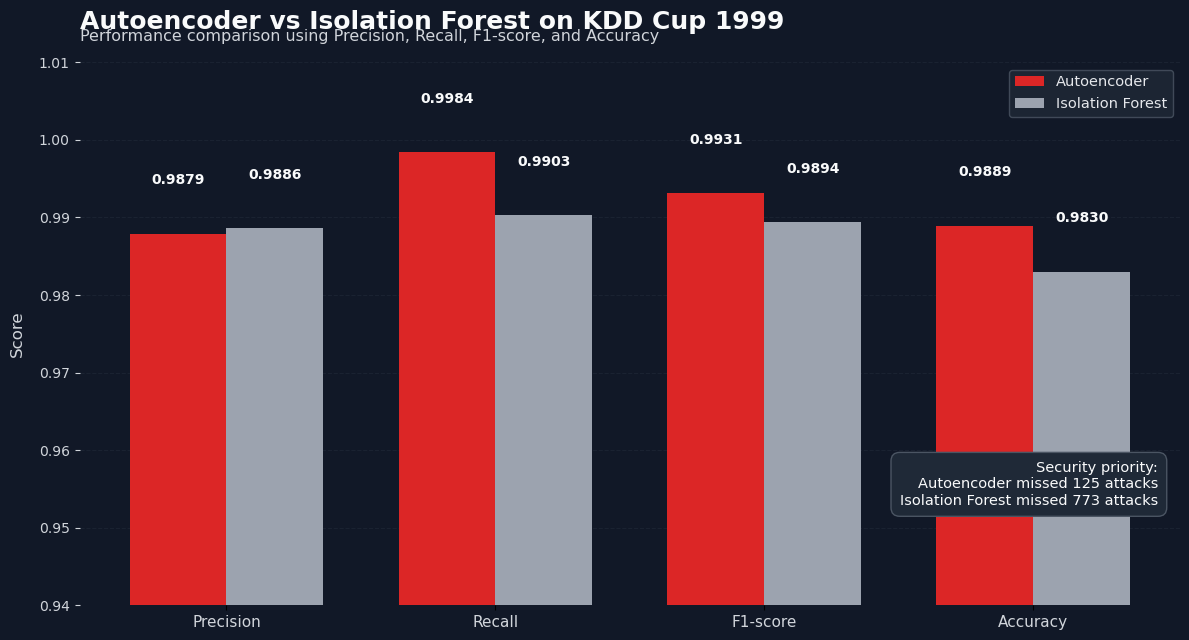

In [23]:
# ============================================================
# Step 13A: Compare Autoencoder vs Isolation Forest
# ============================================================
#
# Goal:
# Compare the neural-network Autoencoder with the traditional
# Isolation Forest baseline.
#
# Previous variables used:
#
# autoencoder_metrics:
# - Created in Step 11A
# - Contains Autoencoder precision, recall, F1-score, and accuracy
#
# if_metrics:
# - Created in Step 12B
# - Contains Isolation Forest precision, recall, F1-score, and accuracy
#
# cm_autoencoder:
# - Created in Step 11A
# - Confusion matrix for Autoencoder
#
# cm_if:
# - Created in Step 12B
# - Confusion matrix for Isolation Forest


# ------------------------------------------------------------
# 1. Combine both model metric tables
# ------------------------------------------------------------

model_comparison = pd.concat(
    [autoencoder_metrics, if_metrics],
    ignore_index=True
)

print("Model comparison table:")
display(model_comparison)


# ------------------------------------------------------------
# 2. Add missed attack and false alarm counts
# ------------------------------------------------------------
#
# Confusion matrix layout:
#
# [[Correct Normal, False Alarm],
#  [Missed Attack, Correct Attack]]
#
# Missed attacks are very important in network security.
# A missed attack means the model predicted "normal"
# when the connection was actually an anomaly.

model_comparison["false_alarms"] = [
    cm_autoencoder[0, 1],
    cm_if[0, 1]
]

model_comparison["missed_attacks"] = [
    cm_autoencoder[1, 0],
    cm_if[1, 0]
]

print("Model comparison with security error counts:")
display(model_comparison)


# ------------------------------------------------------------
# 3. Prepare chart data
# ------------------------------------------------------------

chart_data = model_comparison.copy()

metrics_to_plot = ["precision", "recall", "f1_score", "accuracy"]

x_positions = np.arange(len(metrics_to_plot))

autoencoder_values = chart_data.loc[
    chart_data["model"] == "Autoencoder",
    metrics_to_plot
].values.flatten()

isolation_forest_values = chart_data.loc[
    chart_data["model"] == "Isolation Forest",
    metrics_to_plot
].values.flatten()


# ------------------------------------------------------------
# 4. Create professional grouped bar chart
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 6.5))

# Dark corporate background
fig.patch.set_facecolor("#111827")
ax.set_facecolor("#111827")

bar_width = 0.36

autoencoder_bars = ax.bar(
    x_positions - bar_width / 2,
    autoencoder_values,
    width=bar_width,
    color="#DC2626",
    label="Autoencoder"
)

if_bars = ax.bar(
    x_positions + bar_width / 2,
    isolation_forest_values,
    width=bar_width,
    color="#9CA3AF",
    label="Isolation Forest"
)


# ------------------------------------------------------------
# 5. Add value labels above bars
# ------------------------------------------------------------

for bars in [autoencoder_bars, if_bars]:
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.006,
            f"{height:.4f}",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold",
            color="#F9FAFB"
        )


# ------------------------------------------------------------
# 6. Titles and labels
# ------------------------------------------------------------

ax.set_title(
    "Autoencoder vs Isolation Forest on KDD Cup 1999",
    fontsize=18,
    fontweight="bold",
    loc="left",
    pad=24,
    color="#F9FAFB"
)

ax.text(
    0,
    1.04,
    "Performance comparison using Precision, Recall, F1-score, and Accuracy",
    transform=ax.transAxes,
    fontsize=11.5,
    color="#D1D5DB"
)

ax.set_xticks(x_positions)
ax.set_xticklabels(
    ["Precision", "Recall", "F1-score", "Accuracy"],
    fontsize=11,
    color="#D1D5DB"
)

ax.set_ylabel(
    "Score",
    fontsize=12,
    labelpad=10,
    color="#D1D5DB"
)

ax.set_ylim(0.94, 1.01)


# ------------------------------------------------------------
# 7. Styling
# ------------------------------------------------------------

ax.grid(axis="y", linestyle="--", alpha=0.25, color="#374151")
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(axis="y", colors="#D1D5DB")

legend = ax.legend(
    frameon=True,
    facecolor="#1F2937",
    edgecolor="#4B5563",
    fontsize=10.5
)

for text in legend.get_texts():
    text.set_color("#E5E7EB")


# ------------------------------------------------------------
# 8. Add security-focused insight box
# ------------------------------------------------------------

ax.text(
    0.98,
    0.18,
    "Security priority:\nAutoencoder missed 125 attacks\nIsolation Forest missed 773 attacks",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=10.5,
    color="#F9FAFB",
    bbox=dict(
        boxstyle="round,pad=0.6",
        facecolor="#1F2937",
        edgecolor="#4B5563"
    )
)

plt.tight_layout()
plt.show()

<div style="
background:#111827;
color:#e5e7eb;
border-radius:14px;
font-family:Arial, sans-serif;
line-height:1.6;
border:1px solid #374151;
overflow:hidden;
">

<div style="
background:#0b1220;
padding:18px 24px;
border-bottom:1px solid #374151;
">
<div style="
font-size:12px;
letter-spacing:1.2px;
text-transform:uppercase;
color:#9ca3af;
font-weight:700;
margin-bottom:6px;
">
Expert Section
</div>

<h2 style="
color:#f9fafb;
margin:0;
font-size:22px;
font-weight:800;
">
Step 13A Conclusion — Autoencoder vs Isolation Forest
</h2>
</div>

<div style="padding:24px;">

<p>
The Autoencoder and Isolation Forest were compared on the KDD Cup 1999 test data.
</p>

<table style="width:100%; border-collapse:collapse; color:#e5e7eb; margin:18px 0;">
<tr>
<th style="text-align:left; padding:8px; border-bottom:1px solid #4b5563;">Model</th>
<th style="text-align:left; padding:8px; border-bottom:1px solid #4b5563;">Precision</th>
<th style="text-align:left; padding:8px; border-bottom:1px solid #4b5563;">Recall</th>
<th style="text-align:left; padding:8px; border-bottom:1px solid #4b5563;">F1-score</th>
<th style="text-align:left; padding:8px; border-bottom:1px solid #4b5563;">Accuracy</th>
</tr>
<tr>
<td style="padding:8px;">Autoencoder</td>
<td style="padding:8px;"><strong>0.9879</strong></td>
<td style="padding:8px;"><strong>0.9984</strong></td>
<td style="padding:8px;"><strong>0.9931</strong></td>
<td style="padding:8px;"><strong>0.9889</strong></td>
</tr>
<tr>
<td style="padding:8px;">Isolation Forest</td>
<td style="padding:8px;"><strong>0.9886</strong></td>
<td style="padding:8px;"><strong>0.9903</strong></td>
<td style="padding:8px;"><strong>0.9894</strong></td>
<td style="padding:8px;"><strong>0.9830</strong></td>
</tr>
</table>

<p>
Both models performed strongly, but the <strong>Autoencoder performed better overall</strong>.
</p>

<p>
Isolation Forest had slightly higher precision, but the Autoencoder had better recall, F1-score, and accuracy.
</p>

<table style="width:100%; border-collapse:collapse; color:#e5e7eb; margin:18px 0;">
<tr>
<th style="text-align:left; padding:8px; border-bottom:1px solid #4b5563;">Model</th>
<th style="text-align:left; padding:8px; border-bottom:1px solid #4b5563;">Missed Attacks</th>
<th style="text-align:left; padding:8px; border-bottom:1px solid #4b5563;">False Alarms</th>
</tr>
<tr>
<td style="padding:8px;">Autoencoder</td>
<td style="padding:8px;"><strong>125</strong></td>
<td style="padding:8px;"><strong>974</strong></td>
</tr>
<tr>
<td style="padding:8px;">Isolation Forest</td>
<td style="padding:8px;"><strong>773</strong></td>
<td style="padding:8px;"><strong>910</strong></td>
</tr>
</table>

<p>
For network security, missed attacks are more serious than false alarms.
</p>

<p>
The Autoencoder missed only <strong>125 attacks</strong>, while Isolation Forest missed <strong>773 attacks</strong>.
</p>

<div style="
background:#1f2937;
border-left:4px solid #9ca3af;
padding:15px 18px;
border-radius:10px;
margin-top:20px;
">
<strong style="color:#f3f4f6;">Final interpretation:</strong><br>
The Autoencoder is the stronger model for this KDD Cup 1999 anomaly detection task 

because it catches more attack-like connections and achieves the highest F1-score.
</div>

</div>
</div>

Missed attack comparison:


,model,missed_attacks
0,Autoencoder,125
1,Isolation Forest,773


Autoencoder missed 648 fewer attacks than Isolation Forest.


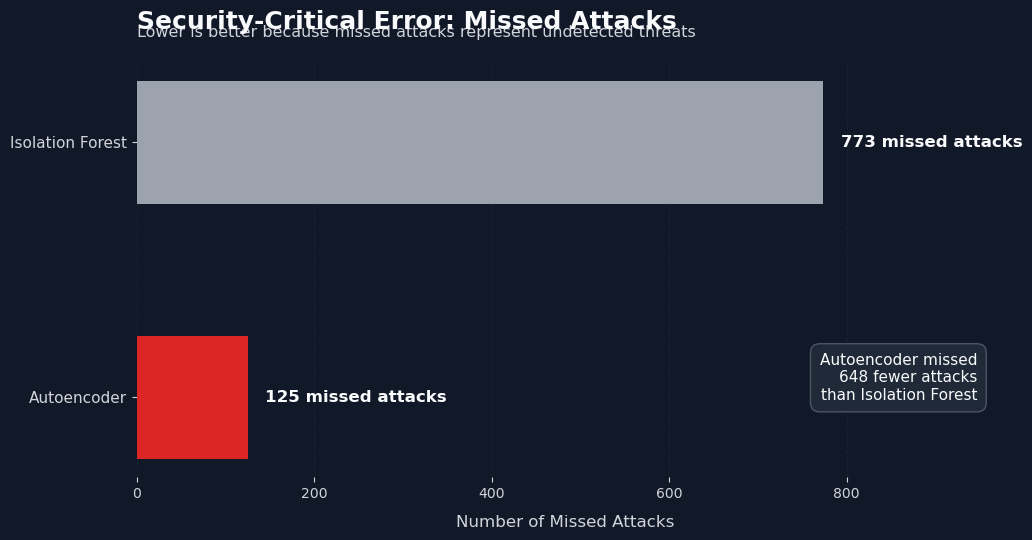

In [25]:
# ============================================================
# Step 13B: Security-critical chart - Missed attacks comparison
# ============================================================
#
# Goal:
# Compare Autoencoder and Isolation Forest using the most important
# security error: missed attacks.
#
# Why:
# In network security, a missed attack is more dangerous than a false alarm.
#
# Missed attack means:
# - actual anomaly
# - predicted normal
# - dangerous because the attack was not detected
#
# Previous variables used:
#
# cm_autoencoder:
# - Autoencoder confusion matrix from Step 11A
#
# cm_if:
# - Isolation Forest confusion matrix from Step 12B
#
# Confusion matrix layout:
#
# [[Correct Normal, False Alarm],
#  [Missed Attack, Correct Attack]]

import matplotlib.pyplot as plt
import pandas as pd

# ------------------------------------------------------------
# 1. Create missed attack comparison table
# ------------------------------------------------------------

missed_attack_comparison = pd.DataFrame({
    "model": ["Autoencoder", "Isolation Forest"],
    "missed_attacks": [
        cm_autoencoder[1, 0],
        cm_if[1, 0]
    ]
})

# Calculate difference
missed_attack_difference = (
    missed_attack_comparison.loc[
        missed_attack_comparison["model"] == "Isolation Forest",
        "missed_attacks"
    ].iloc[0]
    -
    missed_attack_comparison.loc[
        missed_attack_comparison["model"] == "Autoencoder",
        "missed_attacks"
    ].iloc[0]
)

print("Missed attack comparison:")
display(missed_attack_comparison)

print(
    f"Autoencoder missed {missed_attack_difference:,} fewer attacks "
    "than Isolation Forest."
)

# ------------------------------------------------------------
# 2. Create clean horizontal bar chart
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10.5, 5.5))

fig.patch.set_facecolor("#111827")
ax.set_facecolor("#111827")

colors = ["#DC2626", "#9CA3AF"]

bars = ax.barh(
    missed_attack_comparison["model"],
    missed_attack_comparison["missed_attacks"],
    color=colors,
    height=0.48
)

# ------------------------------------------------------------
# 3. Add value labels
# ------------------------------------------------------------

for bar in bars:
    width = bar.get_width()
    ax.text(
        width + 20,
        bar.get_y() + bar.get_height() / 2,
        f"{int(width):,} missed attacks",
        va="center",
        fontsize=12,
        fontweight="bold",
        color="#F9FAFB"
    )

# ------------------------------------------------------------
# 4. Titles and labels
# ------------------------------------------------------------

ax.set_title(
    "Security-Critical Error: Missed Attacks",
    fontsize=18,
    fontweight="bold",
    loc="left",
    pad=24,
    color="#F9FAFB"
)

ax.text(
    0,
    1.06,
    "Lower is better because missed attacks represent undetected threats",
    transform=ax.transAxes,
    fontsize=11.5,
    color="#D1D5DB"
)

ax.set_xlabel(
    "Number of Missed Attacks",
    fontsize=12,
    labelpad=10,
    color="#D1D5DB"
)

ax.set_ylabel("")

# ------------------------------------------------------------
# 5. Styling
# ------------------------------------------------------------

ax.grid(axis="x", linestyle="--", alpha=0.25, color="#374151")
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_visible(False)

ax.tick_params(axis="x", colors="#D1D5DB")
ax.tick_params(axis="y", colors="#D1D5DB", labelsize=11)

ax.set_xlim(0, missed_attack_comparison["missed_attacks"].max() * 1.25)

# ------------------------------------------------------------
# 6. Add insight box
# ------------------------------------------------------------

ax.text(
    0.98,
    0.18,
    f"Autoencoder missed\n{missed_attack_difference:,} fewer attacks\nthan Isolation Forest",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=11,
    color="#F9FAFB",
    bbox=dict(
        boxstyle="round,pad=0.6",
        facecolor="#1F2937",
        edgecolor="#4B5563"
    )
)

plt.tight_layout()
plt.show()

<div style="
background:#111827;
color:#e5e7eb;
border-radius:14px;
font-family:Arial, sans-serif;
line-height:1.6;
border:1px solid #374151;
overflow:hidden;
">

<div style="
background:#0b1220;
padding:18px 24px;
border-bottom:1px solid #374151;
">
<div style="
font-size:12px;
letter-spacing:1.2px;
text-transform:uppercase;
color:#9ca3af;
font-weight:700;
margin-bottom:6px;
">
Expert Section
</div>

<h2 style="
color:#f9fafb;
margin:0;
font-size:22px;
font-weight:800;
">
Step 13B Conclusion — Security Error Comparison
</h2>
</div>

<div style="padding:24px;">

<p>
The security error comparison chart compares the two most important prediction mistakes:
</p>

<ul>
<li><strong>False alarms</strong> — normal connections incorrectly flagged as anomalies</li>
<li><strong>Missed attacks</strong> — anomaly connections incorrectly predicted as normal</li>
</ul>

<table style="width:100%; border-collapse:collapse; color:#e5e7eb; margin:18px 0;">
<tr>
<th style="text-align:left; padding:8px; border-bottom:1px solid #4b5563;">Model</th>
<th style="text-align:left; padding:8px; border-bottom:1px solid #4b5563;">False Alarms</th>
<th style="text-align:left; padding:8px; border-bottom:1px solid #4b5563;">Missed Attacks</th>
</tr>
<tr>
<td style="padding:8px;">Autoencoder</td>
<td style="padding:8px;"><strong>974</strong></td>
<td style="padding:8px;"><strong>125</strong></td>
</tr>
<tr>
<td style="padding:8px;">Isolation Forest</td>
<td style="padding:8px;"><strong>910</strong></td>
<td style="padding:8px;"><strong>773</strong></td>
</tr>
</table>

<p>
Isolation Forest produced slightly fewer false alarms, but it missed many more attacks.
</p>

<p>
The Autoencoder missed <strong>648 fewer attacks</strong> than Isolation Forest.
</p>

<div style="
background:#1f2937;
border-left:4px solid #9ca3af;
padding:15px 18px;
border-radius:10px;
margin-top:20px;
">
<strong style="color:#f3f4f6;">Security interpretation:</strong><br>
In network security, missed attacks are usually more dangerous than false alarms. Therefore, the Autoencoder is the stronger model for this task.
</div>

</div>
</div>

<div style="
background:#111827;
color:#e5e7eb;
border-radius:16px;
font-family:Arial, sans-serif;
line-height:1.6;
border:1px solid #374151;
overflow:hidden;
">

<div style="
background:#0b1220;
padding:22px 28px;
border-bottom:1px solid #374151;
">
<div style="
font-size:12px;
letter-spacing:1.3px;
text-transform:uppercase;
color:#9ca3af;
font-weight:700;
margin-bottom:8px;
">
Expert Section Summary
</div>

<h1 style="
color:#f9fafb;
margin:0;
font-size:26px;
font-weight:800;
line-height:1.25;
">
KDD Cup 1999 — Autoencoder Anomaly Detection
</h1>

<p style="
color:#9ca3af;
margin:10px 0 0 0;
font-size:14px;
">
Prepared by <strong style="color:#d1d5db;">Ruturaj Mokashi</strong>
</p>
</div>

<div style="padding:28px;">

<h2 style="
color:#f3f4f6;
font-size:18px;
border-left:4px solid #6b7280;
padding-left:12px;
">
Project Goal
</h2>

<p>
The goal of this expert section was to detect suspicious network connections using an <strong>Autoencoder</strong>.
</p>

<p>
The KDD Cup 1999 dataset contains network connection records. Each row represents one connection, and the target label tells whether the connection is normal or attack-like.
</p>

<hr style="border:0; border-top:1px solid #374151; margin:24px 0;">

<h2 style="
color:#f3f4f6;
font-size:18px;
border-left:4px solid #6b7280;
padding-left:12px;
">
Workflow Completed
</h2>

<ol>
<li>Loaded the KDD Cup 1999 dataset.</li>
<li>Inspected the original target labels.</li>
<li>Converted the labels into <strong>Normal</strong> vs <strong>Anomaly</strong>.</li>
<li>Corrected feature types.</li>
<li>Split the data into training and testing sets.</li>
<li>Preprocessed numerical and categorical features.</li>
<li>Built an Autoencoder neural network.</li>
<li>Trained the Autoencoder on normal traffic only.</li>
<li>Calculated reconstruction error on the test set.</li>
<li>Selected an anomaly threshold.</li>
<li>Evaluated Autoencoder performance.</li>
<li>Compared Autoencoder with Isolation Forest.</li>
</ol>

<hr style="border:0; border-top:1px solid #374151; margin:24px 0;">

<h2 style="
color:#f3f4f6;
font-size:18px;
border-left:4px solid #6b7280;
padding-left:12px;
">
Dataset Summary
</h2>

<table style="width:100%; border-collapse:collapse; color:#e5e7eb; margin:18px 0;">
<tr>
<th style="text-align:left; padding:8px; border-bottom:1px solid #4b5563;">Item</th>
<th style="text-align:left; padding:8px; border-bottom:1px solid #4b5563;">Value</th>
</tr>
<tr>
<td style="padding:8px;">Total rows</td>
<td style="padding:8px;"><strong>494,021</strong></td>
</tr>
<tr>
<td style="padding:8px;">Original feature columns</td>
<td style="padding:8px;"><strong>41</strong></td>
</tr>
<tr>
<td style="padding:8px;">Processed feature count</td>
<td style="padding:8px;"><strong>74</strong></td>
</tr>
<tr>
<td style="padding:8px;">Normal rows</td>
<td style="padding:8px;"><strong>97,278</strong></td>
</tr>
<tr>
<td style="padding:8px;">Anomaly rows</td>
<td style="padding:8px;"><strong>396,743</strong></td>
</tr>
</table>

<p>
The dataset was strongly dominated by anomaly records, with anomalies representing <strong>80.31%</strong> of the data.
</p>

<hr style="border:0; border-top:1px solid #374151; margin:24px 0;">

<h2 style="
color:#f3f4f6;
font-size:18px;
border-left:4px solid #6b7280;
padding-left:12px;
">
Autoencoder Setup
</h2>

<table style="width:100%; border-collapse:collapse; color:#e5e7eb; margin:18px 0;">
<tr>
<th style="text-align:left; padding:8px; border-bottom:1px solid #4b5563;">Model Part</th>
<th style="text-align:left; padding:8px; border-bottom:1px solid #4b5563;">Structure</th>
</tr>
<tr>
<td style="padding:8px;">Input</td>
<td style="padding:8px;"><strong>74 features</strong></td>
</tr>
<tr>
<td style="padding:8px;">Encoder</td>
<td style="padding:8px;"><strong>64 → 32 neurons</strong></td>
</tr>
<tr>
<td style="padding:8px;">Bottleneck</td>
<td style="padding:8px;"><strong>16 neurons</strong></td>
</tr>
<tr>
<td style="padding:8px;">Decoder</td>
<td style="padding:8px;"><strong>32 → 64 neurons</strong></td>
</tr>
<tr>
<td style="padding:8px;">Output</td>
<td style="padding:8px;"><strong>74 reconstructed features</strong></td>
</tr>
</table>

<p>
The Autoencoder was trained on <strong>normal network traffic only</strong>. The model learned how normal connections should look, then used reconstruction error to detect suspicious rows.
</p>

<hr style="border:0; border-top:1px solid #374151; margin:24px 0;">

<h2 style="
color:#f3f4f6;
font-size:18px;
border-left:4px solid #6b7280;
padding-left:12px;
">
Final Model Comparison
</h2>

<table style="width:100%; border-collapse:collapse; color:#e5e7eb; margin:18px 0;">
<tr>
<th style="text-align:left; padding:8px; border-bottom:1px solid #4b5563;">Model</th>
<th style="text-align:left; padding:8px; border-bottom:1px solid #4b5563;">Precision</th>
<th style="text-align:left; padding:8px; border-bottom:1px solid #4b5563;">Recall</th>
<th style="text-align:left; padding:8px; border-bottom:1px solid #4b5563;">F1-score</th>
<th style="text-align:left; padding:8px; border-bottom:1px solid #4b5563;">Accuracy</th>
</tr>
<tr>
<td style="padding:8px;">Autoencoder</td>
<td style="padding:8px;"><strong>0.9879</strong></td>
<td style="padding:8px;"><strong>0.9984</strong></td>
<td style="padding:8px;"><strong>0.9931</strong></td>
<td style="padding:8px;"><strong>0.9889</strong></td>
</tr>
<tr>
<td style="padding:8px;">Isolation Forest</td>
<td style="padding:8px;"><strong>0.9886</strong></td>
<td style="padding:8px;"><strong>0.9903</strong></td>
<td style="padding:8px;"><strong>0.9894</strong></td>
<td style="padding:8px;"><strong>0.9830</strong></td>
</tr>
</table>

<table style="width:100%; border-collapse:collapse; color:#e5e7eb; margin:18px 0;">
<tr>
<th style="text-align:left; padding:8px; border-bottom:1px solid #4b5563;">Model</th>
<th style="text-align:left; padding:8px; border-bottom:1px solid #4b5563;">False Alarms</th>
<th style="text-align:left; padding:8px; border-bottom:1px solid #4b5563;">Missed Attacks</th>
</tr>
<tr>
<td style="padding:8px;">Autoencoder</td>
<td style="padding:8px;"><strong>974</strong></td>
<td style="padding:8px;"><strong>125</strong></td>
</tr>
<tr>
<td style="padding:8px;">Isolation Forest</td>
<td style="padding:8px;"><strong>910</strong></td>
<td style="padding:8px;"><strong>773</strong></td>
</tr>
</table>

<div style="
background:#1f2937;
border:1px solid #4b5563;
border-left:4px solid #9ca3af;
padding:18px;
border-radius:12px;
margin-top:24px;
">

<h2 style="
color:#f9fafb;
font-size:18px;
margin-top:0;
">
Final Winner — Autoencoder
</h2>

<p>
The <strong>Autoencoder</strong> was the stronger model for this KDD Cup 1999 anomaly detection task.
</p>

<p>
It achieved the highest F1-score and recall, and it missed far fewer attacks than Isolation Forest.
</p>

<p style="margin-bottom:0;">
For network security, missed attacks are more dangerous than false alarms. Since the Autoencoder missed only <strong>125 attacks</strong> compared with <strong>773 missed attacks</strong> by Isolation Forest, it is the better choice for this task.
</p>

</div>

</div>
</div>